# Spectral Analysis — Consolidated Results (All Phases)

**Goal**: Re-run all analysis on cached entropy trajectory PKLs using the full 16-feature set
with z-score normalization. Produces updated official Nadler AUROC numbers and a complete set
of publication-quality plots for every domain and model.

**GPU required**: NO — all data already cached on Drive. Run on a CPU-only Colab runtime.

**Sections**:
1. Setup
2. MATH-500 (4 models, Phases 4/5)
3. GSM8K (1 model, Phase 7)
4. GPQA Diamond (5 models, Phases 4/5/8)
5. RAG L-CiteEval (4 × 4 = 16 cells, Phase 10)
6. Factual QA — negative result (Phase 9)
7. Global cross-domain analysis
8. Summary + save

## Section 1 — Setup

In [1]:
import os, sys, shutil, pickle, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
from google.colab import drive
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

REPO_DIR = '/content/hallucination_detection'
BRANCH   = 'feature/meta-agentic-integration'  # branch with 16-feature FEAT_NAMES

if os.path.exists(REPO_DIR) and not os.path.exists(os.path.join(REPO_DIR, 'spectral_utils')):
    shutil.rmtree(REPO_DIR)
if not os.path.exists(REPO_DIR):
    os.system(f'git clone -b {BRANCH} https://github.com/omrisegev/hallucination_detection.git {REPO_DIR}')
else:
    os.system(f'git -C {REPO_DIR} pull -q')
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

os.system('pip install -q scipy seaborn tqdm scikit-learn')

from spectral_utils import (
    extract_all_features, sw_var_peak_adaptive, FEAT_NAMES,
    zscore, boot_auc, nadler_fuse, simple_average_fusion, best_nadler_on,
    segment_by_citations, lciteeval_grounding_label,
)

assert len(FEAT_NAMES) == 16, f"Expected 16 features, got {len(FEAT_NAMES)}"
print(f'spectral_utils imported OK | FEAT_NAMES ({len(FEAT_NAMES)}): {FEAT_NAMES}')

Mounted at /content/drive
spectral_utils imported OK | FEAT_NAMES (16): ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power', 'hl_ratio', 'dominant_freq', 'spectral_centroid', 'stft_max_high_power', 'stft_spectral_entropy', 'rpdi', 'sw_var_peak', 'pe_mean', 'hurst_exponent', 'cusum_max', 'cusum_shift_idx']


In [2]:
BASE     = '/content/drive/MyDrive'
HALL_DIR = f'{BASE}/hallucination_detection'
OUT_DIR  = f'{HALL_DIR}/consolidated_results'
PLOT_DIR = f'{OUT_DIR}/plots'
RAG_FEAT_DIR = f'{OUT_DIR}/rag_feats'
os.makedirs(PLOT_DIR,    exist_ok=True)
os.makedirs(RAG_FEAT_DIR, exist_ok=True)

# Auto-detect phase4 vs phase5 — Drive folder may be named either way
_math_gpqa_candidates = [
    f'{BASE}/epr_spectral_phase4',
    f'{BASE}/epr_spectral_phase5',
    f'{HALL_DIR}/epr_spectral_phase4',
    f'{HALL_DIR}/epr_spectral_phase5',
]
_math_gpqa = next((p for p in _math_gpqa_candidates if os.path.exists(p)),
                  _math_gpqa_candidates[0])
print(f'math_gpqa path: {_math_gpqa} (exists={os.path.exists(_math_gpqa)})')

DATA_ROOTS = {
    'math_gpqa':  _math_gpqa,                            # Phase 4+5: MATH-500 + GPQA
    'gsm8k':      f'{BASE}/epr_spectral_gsm8k_vs_lapei', # Phase 7: Llama-3.1-8B on GSM8K
    'gpqa_72b':   f'{BASE}/epr_spectral_gpqa_72b',       # Phase 8: Qwen-72B-AWQ on GPQA
    'qa_cot':     f'{BASE}/spectral_phase9_cache',        # Phase 9: TriviaQA + WebQ CoT
    'rag_raw':    f'{HALL_DIR}/cache/phase10_main/raw',  # Phase 10: 4×4 RAG raw trajectories
}

# Short display names for model keys
MODEL_DISPLAY = {
    'Qwen2.5-Math-7B-Instruct': 'Qwen-Math-7B',
    'Qwen2.5-Math-1.5B':        'Qwen-Math-1.5B',
    'DeepSeek-Math-7B':         'DeepSeek-Math-7B',
    'R1-Distill-Llama-8B':      'R1-Llama-8B',
    'Mistral-7B-Instruct-v0.2': 'Mistral-7B',
    'Qwen2.5-7B-Instruct':      'Qwen-7B',
    'Llama-3.1-8B-Instruct':    'Llama-8B',
    'qwen25_7b':  'Qwen-7B', 'qwen7b':     'Qwen-7B',
    'mistral24b': 'Mistral-24B',
    'qwen72b':    'Qwen-72B', 'Qwen2.5-72B-AWQ': 'Qwen-72B',
    'llama8b':    'Llama-8B',
}

# Check paths exist
for name, path in DATA_ROOTS.items():
    status = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  [{status}] {name}: {path}')

math_gpqa path: /content/drive/MyDrive/epr_spectral_phase4 (exists=True)
  [OK] math_gpqa: /content/drive/MyDrive/epr_spectral_phase4
  [OK] gsm8k: /content/drive/MyDrive/epr_spectral_gsm8k_vs_lapei
  [OK] gpqa_72b: /content/drive/MyDrive/epr_spectral_gpqa_72b
  [OK] qa_cot: /content/drive/MyDrive/spectral_phase9_cache
  [OK] rag_raw: /content/drive/MyDrive/hallucination_detection/cache/phase10_main/raw


## Section 2 — Data Loading

In [3]:
def _extract_temp_from_path(path_str):
    """Infer temperature from folder/filename string."""
    for part in path_str.replace('/', '__').split('__'):
        try:
            v = float(part)
            if 0.3 <= v <= 2.0: return v
        except ValueError:
            pass
    if 'T1.5' in path_str or 't1.5' in path_str: return 1.5
    if 'T1.0' in path_str or 't1.0' in path_str: return 1.0
    if 'T0.7' in path_str or 't0.7' in path_str: return 0.7
    return 1.0  # default


def _parse_model_dataset_from_path(fpath):
    """Extract (model_key, dataset_key, temperature) from a PKL file path."""
    fname   = os.path.basename(fpath)
    pdir    = os.path.basename(os.path.dirname(fpath))
    # Pattern 1: filename is "[model]__[dataset].pkl"
    stem = fname.replace('.pkl', '')
    if '__' in stem:
        parts = stem.split('__')
        return parts[0], parts[1] if len(parts) > 1 else 'unknown', _extract_temp_from_path(fpath)
    # Pattern 2: file is "inference_cache.pkl" inside "[model]__[dataset]/" folder
    if '__' in pdir:
        parts = pdir.split('__')
        return parts[0], parts[1] if len(parts) > 1 else 'unknown', _extract_temp_from_path(pdir)
    # Pattern 3: folder is the model name, file encodes dataset
    return pdir, stem, _extract_temp_from_path(fpath)


def load_samples_from_pkl(fpath, ltype='binary'):
    """Load raw samples from a PKL file. Returns list of dicts with ents+label+text."""
    try:
        with open(fpath, 'rb') as f: data = pickle.load(f)
    except Exception as e:
        print(f'  load error {fpath}: {e}')
        return []

    if isinstance(data, list):
        raw = data
    elif isinstance(data, dict):
        if 'results' in data: raw = data['results']
        elif 'data'    in data: raw = data['data']
        else: raw = list(data.values())
    else:
        return []

    samples = []
    for sample in raw:
        if not isinstance(sample, dict): continue
        src   = sample.get('output', sample)
        text  = src.get('generated_text', src.get('full_text', src.get('text', '')))
        ents  = src.get('token_entropies', src.get('all_ents',
                src.get('all_entropies', src.get('entropies', src.get('ents')))))
        offs  = src.get('token_offsets', src.get('offsets'))
        label = sample.get('is_correct', sample.get('label',
                sample.get('grounding', sample.get('correct'))))

        if ents is None or len(ents) < 3: continue
        ents = np.array(ents, dtype=float)

        if ltype == 'statement':
            # Phase 10 RAG: segment by citation markers
            if text is None or offs is None or 'row' not in sample: continue
            try:
                for seg in segment_by_citations(text, offs):
                    s_label = lciteeval_grounding_label(seg['citation_ids'], sample['row'])
                    if s_label is None: continue
                    h_slice = ents[seg['token_start']:seg['token_end']]
                    if len(h_slice) < 3: continue
                    samples.append({'ents': h_slice, 'label': int(s_label), 'text': text})
            except Exception:
                continue
        else:
            if label is None: continue
            samples.append({'ents': ents, 'label': int(bool(label)), 'text': text or ''})
    return samples


def load_domain_data(root_path, ltype='binary', min_trace_len=3):
    """Walk root_path and return dict: {(model_key, dataset_key, temp): [samples]}."""
    result = {}
    if not os.path.exists(root_path):
        print(f'  [SKIP] not found: {root_path}')
        return result
    pkls = []
    for r, _, files in os.walk(root_path):
        for f in files:
            if f.endswith('.pkl') and 'summary' not in f and 'final_result' not in f:
                pkls.append(os.path.join(r, f))
    print(f'  Found {len(pkls)} PKL files in {root_path}')
    for fpath in tqdm(pkls):
        model_key, dataset_key, temp = _parse_model_dataset_from_path(fpath)
        samps = load_samples_from_pkl(fpath, ltype=ltype)
        if not samps: continue
        key = (model_key, dataset_key, temp)
        result.setdefault(key, []).extend(samps)
    return result


print('Loader functions defined.')

Loader functions defined.


In [4]:
def extract_feats(samples, use_adaptive_window=False):
    """Extract 16 features from a list of sample dicts. Returns (feats_dict, labels_arr)."""
    rows, labels = [], []
    for s in samples:
        f = extract_all_features(s['ents'])
        if f is None:  # trace too short for spectral analysis
            continue
        if use_adaptive_window:
            f['sw_var_peak'] = sw_var_peak_adaptive(s['ents'])
        rows.append(f)
        labels.append(s['label'])
    feats_dict = {k: np.array([r[k] for r in rows]) for k in FEAT_NAMES}
    return feats_dict, np.array(labels, dtype=int)


def run_nadler(feats_dict, labels, key_str):
    """Run best_nadler_on + simple_average on same subset. Returns result dict."""
    if len(set(labels)) < 2:
        print(f'  [{key_str}] only one class — skip')
        return None
    n_pos = labels.sum(); n_neg = len(labels) - n_pos
    # Individual AUCs
    ind_aucs = {}
    for fn in FEAT_NAMES:
        try:
            a = roc_auc_score(labels, feats_dict[fn])
            ind_aucs[fn] = max(a, 1-a)
        except Exception:
            ind_aucs[fn] = 0.5
    # Nadler fusion
    try:
        na, ci_lo, ci_hi, subset, weights = best_nadler_on(
            feats_dict, FEAT_NAMES, labels, max_size=4)
    except Exception as e:
        print(f'  [{key_str}] Nadler error: {e}')
        return None
    # Simple average on same subset
    sa_views = [zscore(feats_dict[fn]) for fn in subset]
    sa_fused, _ = simple_average_fusion(*sa_views)
    try:
        sa = roc_auc_score(labels, sa_fused); sa = max(sa, 1-sa)
    except Exception:
        sa = 0.5
    print(f'  [{key_str}] N={len(labels)} (+{n_pos}/-{n_neg}) | '
          f'Nadler={na:.3f} [{ci_lo:.3f}-{ci_hi:.3f}] | '
          f'Simple={sa:.3f} | Lift={na-sa:+.3f} | Subset={subset}')
    return {'n': len(labels), 'n_pos': int(n_pos), 'n_neg': int(n_neg),
            'ind_aucs': ind_aucs,
            'nadler_auc': na, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
            'best_subset': list(subset), 'best_weights': list(weights),
            'simple_avg_auc': sa, 'lift': na - sa}


print('Analysis helpers defined.')

Analysis helpers defined.


In [5]:
PALETTE = {'correct': '#2166ac', 'hallucinated': '#d6604d'}
PLT_RC  = {'font.size': 10, 'axes.labelsize': 10, 'axes.titlesize': 11,
           'figure.dpi': 150, 'savefig.dpi': 150, 'savefig.bbox': 'tight'}
plt.rcParams.update(PLT_RC)


def plot_feature_auc_bar(results_by_key, title, fname):
    """Grouped bar chart: features × models, bar height = individual AUC."""
    valid = {k: v for k, v in results_by_key.items() if v}
    if not valid: return
    models = list(valid.keys())
    all_ind = {m: valid[m]['ind_aucs'] for m in models}
    # Sort features by best model's AUC descending
    best_m = max(models, key=lambda m: valid[m]['nadler_auc'])
    feats_sorted = sorted(FEAT_NAMES, key=lambda f: all_ind[best_m].get(f, 0.5), reverse=True)

    x = np.arange(len(feats_sorted))
    width = 0.8 / max(len(models), 1)
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = plt.cm.tab10(np.linspace(0, 0.8, len(models)))
    for i, m in enumerate(models):
        heights = [all_ind[m].get(f, 0.5) for f in feats_sorted]
        bars = ax.bar(x + i*width - 0.4 + width/2, heights, width, label=m, color=colors[i], alpha=0.85)
        # Highlight winning Nadler subset in gold
        for j, f in enumerate(feats_sorted):
            if f in valid[m]['best_subset']:
                bars[j].set_edgecolor('gold'); bars[j].set_linewidth(2)
    ax.axhline(0.5, color='gray', linestyle='--', lw=0.8, label='Chance')
    ax.set_xticks(x); ax.set_xticklabels(feats_sorted, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('AUROC'); ax.set_ylim(0.4, 1.0); ax.set_title(title)
    ax.legend(fontsize=8, loc='upper right')
    fig.tight_layout()
    p = os.path.join(PLOT_DIR, fname)
    fig.savefig(p); print(f'saved {p}'); plt.show()


def plot_nadler_summary(results_by_key, title, fname):
    """Horizontal bar chart: one bar per (model,temp), sorted by Nadler AUC."""
    valid = [(k, v) for k, v in results_by_key.items() if v]
    if not valid: return
    valid.sort(key=lambda x: x[1]['nadler_auc'])
    labels = [k for k, _ in valid]
    vals   = [v['nadler_auc'] for _, v in valid]
    ci_lo  = [v['nadler_auc'] - v['ci_lo'] for _, v in valid]
    ci_hi  = [v['ci_hi'] - v['nadler_auc'] for _, v in valid]
    fig, ax = plt.subplots(figsize=(8, max(3, len(valid)*0.5 + 1.5)))
    colors = ['#d6604d' if v < 0.65 else '#fdae61' if v < 0.75 else '#1a9641' for v in vals]
    ax.barh(range(len(valid)), vals, xerr=[ci_lo, ci_hi], color=colors,
            capsize=4, height=0.6, alpha=0.85)
    ax.axvline(0.5, color='gray', linestyle='--', lw=0.8)
    ax.set_yticks(range(len(valid))); ax.set_yticklabels(labels)
    ax.set_xlabel('Nadler AUROC (16 feat, z-score)'); ax.set_title(title)
    ax.set_xlim(0.45, 1.0)
    for i, (k, v) in enumerate(valid):
        ax.text(vals[i] + 0.005, i, f'{vals[i]:.3f}', va='center', fontsize=9)
    fig.tight_layout()
    p = os.path.join(PLOT_DIR, fname)
    fig.savefig(p); print(f'saved {p}'); plt.show()


def plot_trajectories(samples, title, fname, n_each=3):
    """Show n_each correct + n_each hallucinated H(n) traces with annotations."""
    correct   = [s for s in samples if s['label'] == 1][:n_each]
    incorrect = [s for s in samples if s['label'] == 0][:n_each]
    if not correct or not incorrect: return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    for ax, group, color, lab in [(axes[0], correct, PALETTE['correct'], 'Correct'),
                                   (axes[1], incorrect, PALETTE['hallucinated'], 'Hallucinated')]:
        for i, s in enumerate(group):
            ents = s['ents']
            ax.plot(ents, color=color, alpha=0.7, lw=1.2, label=lab if i==0 else '_')
            # Mark cusum_max position
            cs = np.cumsum(ents - ents.mean())
            peak_idx = np.argmax(np.abs(cs))
            ax.axvline(peak_idx, color='gray', linestyle=':', alpha=0.5, lw=0.8)
        ax.set_title(f'{lab} (n={len(group)})', color=color)
        ax.set_xlabel('Token index'); ax.set_ylabel('H(n) entropy')
        ax.legend(fontsize=8)
    fig.suptitle(title); fig.tight_layout()
    p = os.path.join(PLOT_DIR, fname)
    fig.savefig(p); print(f'saved {p}'); plt.show()


def plot_avg_psd(samples_by_key, title, fname):
    """Average PSD (correct vs incorrect) per model. Multi-panel if >2 models."""
    valid = {k: v for k, v in samples_by_key.items() if v}
    if not valid: return
    n_panels = len(valid)
    fig, axes = plt.subplots(1, n_panels, figsize=(5*n_panels, 4), sharey=True)
    if n_panels == 1: axes = [axes]
    for ax, (key, samples) in zip(axes, valid.items()):
        correct   = [s['ents'] for s in samples if s['label'] == 1]
        incorrect = [s['ents'] for s in samples if s['label'] == 0]
        for group, color, lab in [(correct, PALETTE['correct'], 'Correct'),
                                   (incorrect, PALETTE['hallucinated'], 'Hallucinated')]:
            if not group: continue
            psds = []
            for ents in group:
                e = np.array(ents); e_ac = e - e.mean()
                psd = np.abs(np.fft.rfft(e_ac))**2
                psd = psd / (psd.sum() + 1e-12)
                psds.append(psd)
            min_len = min(len(p) for p in psds)
            psds = np.array([p[:min_len] for p in psds])
            freqs = np.fft.rfftfreq(2*(min_len-1))[:min_len]
            # exclude DC (index 0)
            ax.plot(freqs[1:], psds[:,1:].mean(axis=0), color=color, lw=1.5, label=lab)
            ax.fill_between(freqs[1:],
                             psds[:,1:].mean(0) - psds[:,1:].std(0),
                             psds[:,1:].mean(0) + psds[:,1:].std(0),
                             color=color, alpha=0.15)
        ax.set_title(str(key)[:30]); ax.set_xlabel('Normalized freq'); ax.legend(fontsize=8)
        ax.axvspan(0.0, 0.10, alpha=0.05, color='blue', label='Low band')
        ax.axvspan(0.40, 0.50, alpha=0.05, color='red', label='High band')
    fig.suptitle(title); fig.tight_layout()
    p = os.path.join(PLOT_DIR, fname)
    fig.savefig(p); print(f'saved {p}'); plt.show()


def plot_feature_distributions(samples, result, title, fname, top_n=5):
    """Violin plots for top-N features by individual AUC, split correct/hallucinated."""
    if result is None: return
    top_feats = sorted(result['ind_aucs'], key=result['ind_aucs'].get, reverse=True)[:top_n]
    correct   = [s for s in samples if s['label'] == 1]
    incorrect = [s for s in samples if s['label'] == 0]
    if not correct or not incorrect: return

    def _get_feat(samps, fn):
        return [extract_all_features(s['ents']).get(fn, np.nan) for s in samps]

    fig, axes = plt.subplots(1, top_n, figsize=(3*top_n, 4))
    for ax, fn in zip(axes, top_feats):
        c_vals = _get_feat(correct, fn)
        h_vals = _get_feat(incorrect, fn)
        parts = ax.violinplot([c_vals, h_vals], positions=[0, 1], showmedians=True)
        parts['bodies'][0].set_facecolor(PALETTE['correct'])
        parts['bodies'][1].set_facecolor(PALETTE['hallucinated'])
        ax.set_xticks([0, 1]); ax.set_xticklabels(['Correct', 'Hallu.'], fontsize=8)
        ax.set_title(f'{fn}\n(AUC={result["ind_aucs"][fn]:.2f})', fontsize=8)
        if fn in result['best_subset']:
            ax.set_facecolor('#ffffd4')
    fig.suptitle(title); fig.tight_layout()
    p = os.path.join(PLOT_DIR, fname)
    fig.savefig(p); print(f'saved {p}'); plt.show()


print('Plot helpers defined.')

Plot helpers defined.


## Section 2 — MATH-500 (Phases 4/5)

In [6]:
print('Loading MATH-500 caches...')
_math_raw = load_domain_data(DATA_ROOTS['math_gpqa'], ltype='binary')

# Split into MATH-500 vs GPQA by dataset key
MATH500_DATA, GPQA_DATA = {}, {}
for (model, dataset, temp), samps in _math_raw.items():
    key = f'{MODEL_DISPLAY.get(model, model)}_T{temp}'
    ds_lower = dataset.lower()
    if 'math' in ds_lower or 'math500' in ds_lower or 'math-500' in ds_lower:
        MATH500_DATA.setdefault(key, []).extend(samps)
    elif 'gpqa' in ds_lower:
        GPQA_DATA.setdefault(key, []).extend(samps)

print(f'\nMATH-500 groups: {[(k, len(v)) for k, v in MATH500_DATA.items()]}')
print(f'GPQA groups (from phase4/5): {[(k, len(v)) for k, v in GPQA_DATA.items()]}')

Loading MATH-500 caches...
  Found 16 PKL files in /content/drive/MyDrive/epr_spectral_phase4


  0%|          | 0/16 [00:00<?, ?it/s]


MATH-500 groups: [('Qwen2.5-Math-1.5B-Instruct_T1.0', 300), ('Qwen-Math-7B_T1.0', 300), ('deepseek-math-7b-instruct_T1.0', 300), ('DeepSeek-R1-Distill-Llama-8B_T1.0', 300)]
GPQA groups (from phase4/5): [('Llama-8B_T1.0', 198), ('Qwen-7B_T1.0', 198), ('DeepSeek-R1-Distill-Llama-8B_T1.0', 198), ('Mistral-7B_T1.0', 198)]


In [7]:
# ── Nadler analysis per model/temp ──────────────────────────────────────────
RES_PATH = os.path.join(OUT_DIR, 'math500_res.pkl')
FORCE = False

def _valid_res(res): return bool(res) and any(v for v in res.values() if v)

_skip = False
if not FORCE and 'MATH500_RES' in globals() and _valid_res(MATH500_RES) and len(MATH500_RES) == len(MATH500_DATA):
    print('already in memory'); _skip = True
elif not FORCE and os.path.exists(RES_PATH):
    with open(RES_PATH, 'rb') as _f: saved = pickle.load(_f)
    _r, _ft = saved.get('results', {}), saved.get('feats', {})
    if _valid_res(_r):
        MATH500_RES, MATH500_FEATS = _r, _ft
        print(f'loaded {len(MATH500_RES)} results'); _skip = True
    else:
        print('stale pkl (all-None results) — recomputing')

if not _skip:
    MATH500_FEATS, MATH500_RES = {}, {}
    for key, samps in MATH500_DATA.items():
        print(f'\n[MATH-500 / {key}]')
        fd, lbl = extract_feats(samps, use_adaptive_window=False)
        MATH500_FEATS[key] = (fd, lbl)
        MATH500_RES[key]   = run_nadler(fd, lbl, key)
    with open(RES_PATH, 'wb') as _f:
        pickle.dump({'results': MATH500_RES, 'feats': MATH500_FEATS}, _f)
    print(f'\nSaved {len(MATH500_RES)} results to {RES_PATH}')

loaded 4 results


saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/math500_feature_auc_bar.png


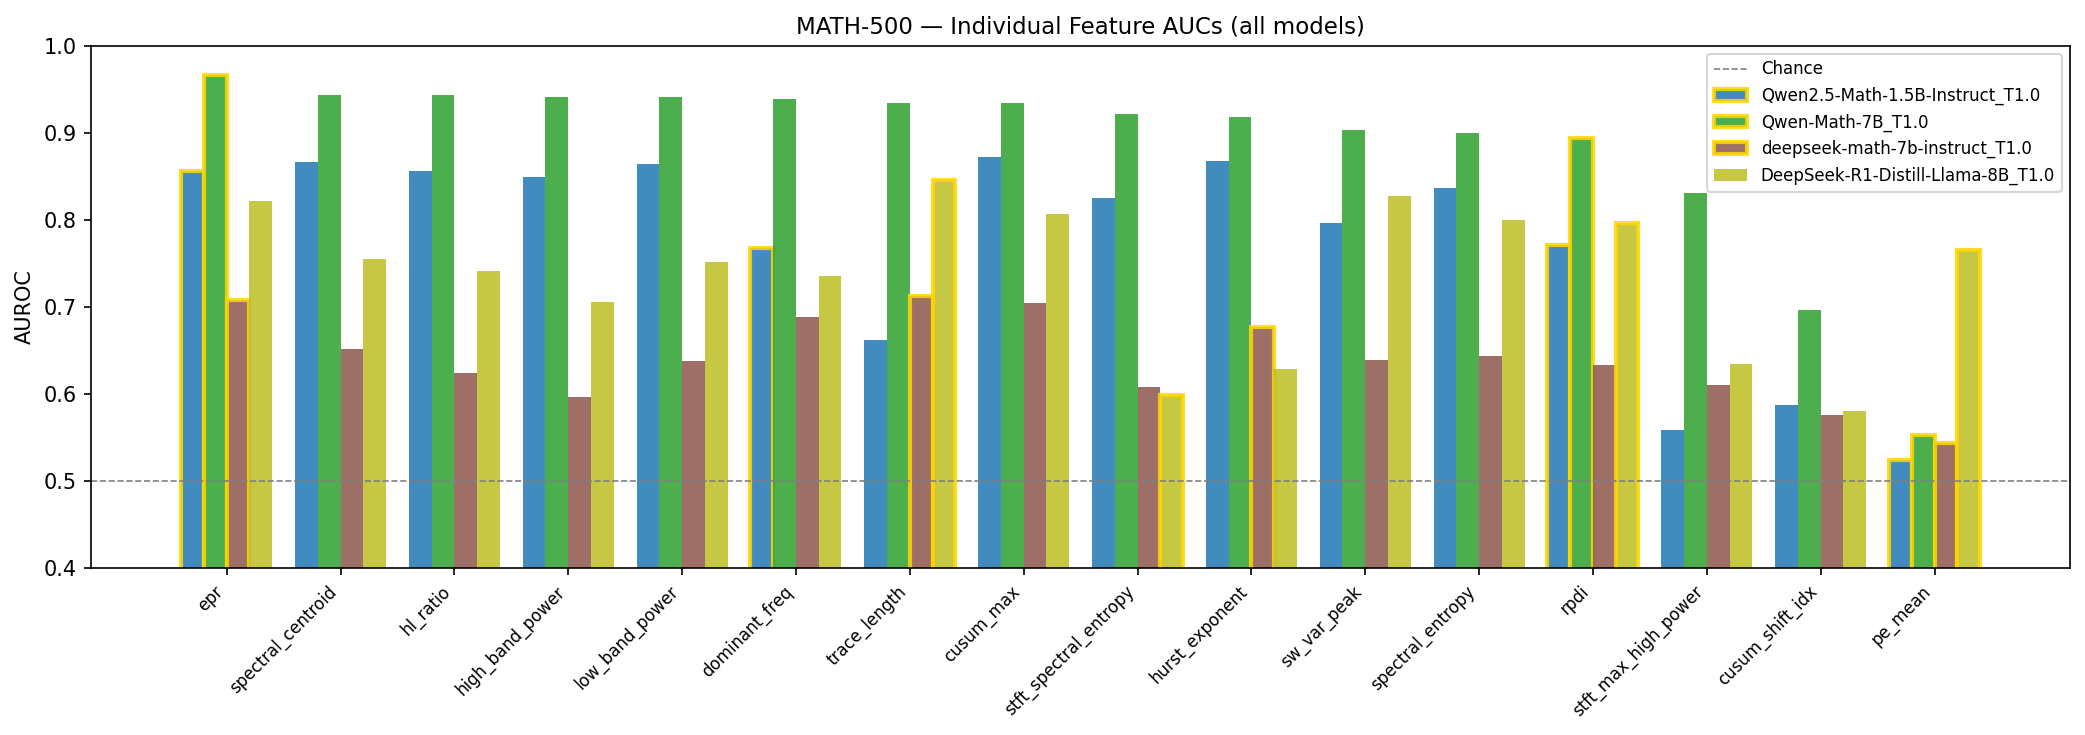

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/math500_nadler_summary.png


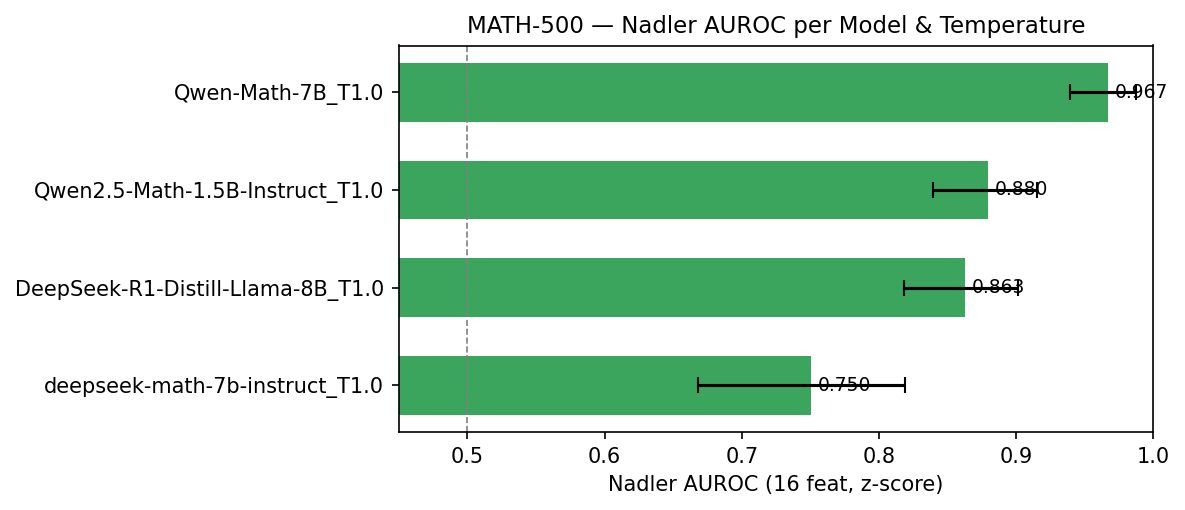

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/math500_Qwen-Math-7B_T1.0_trajectories.png


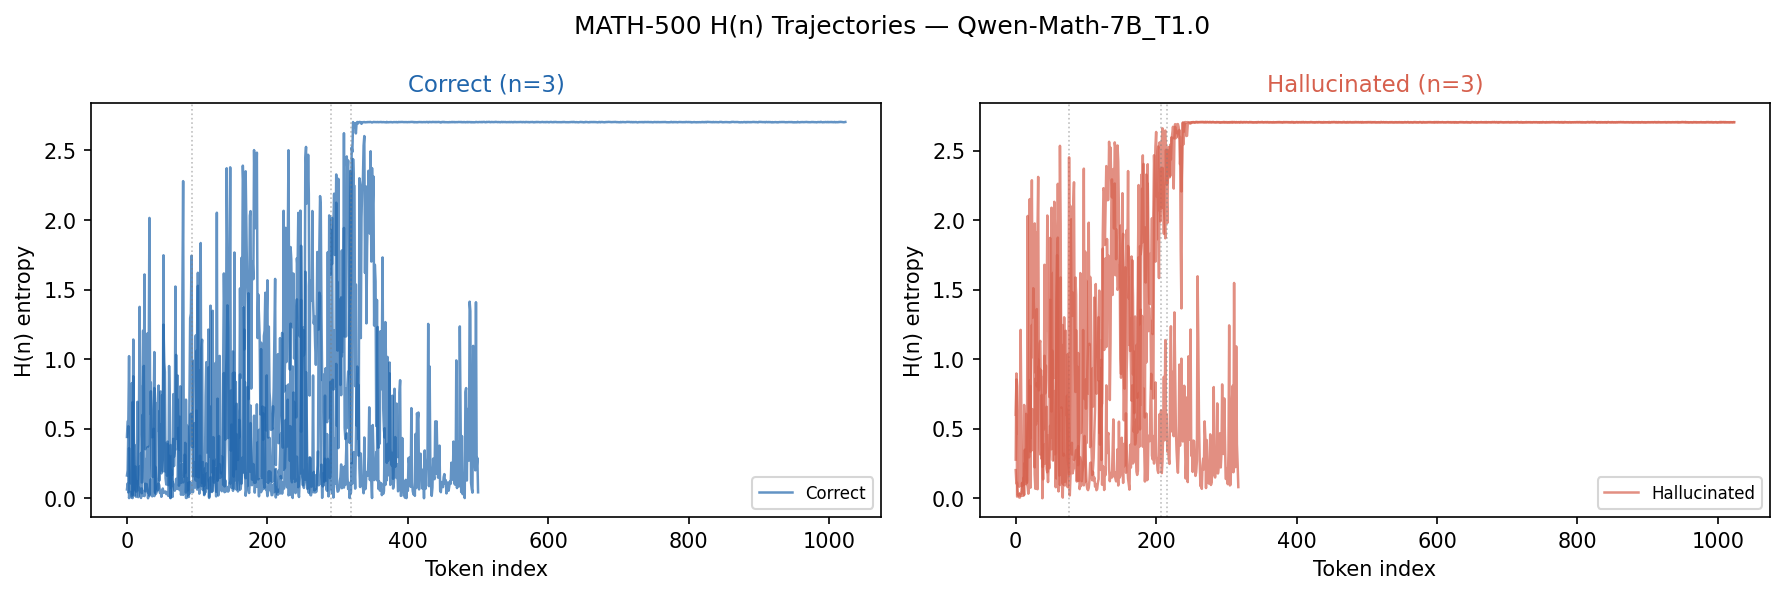

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/math500_avg_psd.png


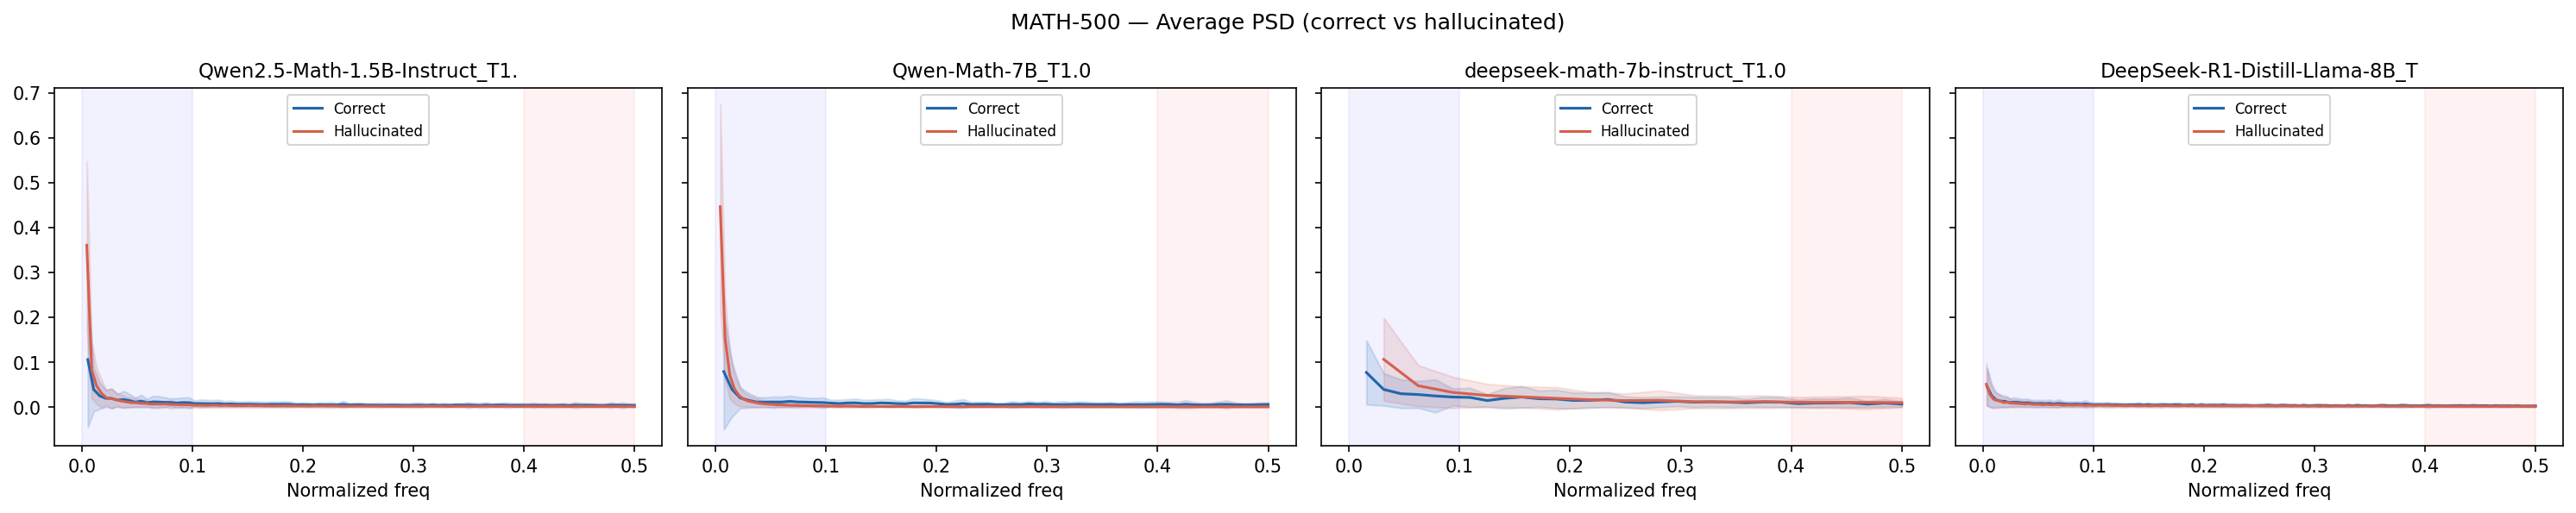

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/math500_Qwen-Math-7B_T1.0_distributions.png


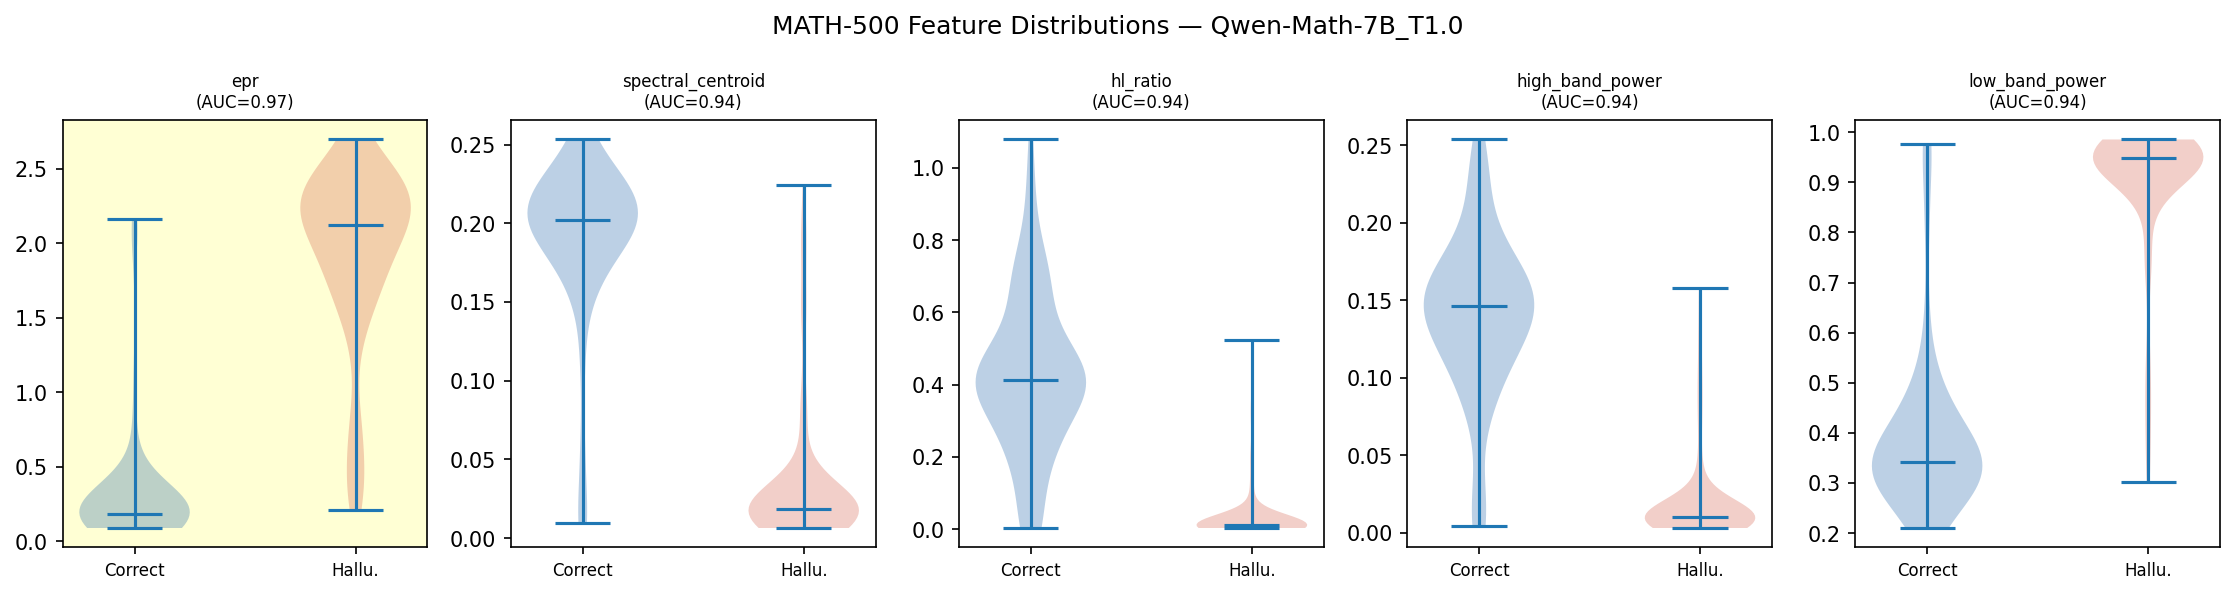

In [8]:
# ── MATH-500 Plots ───────────────────────────────────────────────────────────
valid_math = {k: v for k, v in MATH500_RES.items() if v}

plot_feature_auc_bar(valid_math, 'MATH-500 — Individual Feature AUCs (all models)',
                     'math500_feature_auc_bar.png')

plot_nadler_summary(MATH500_RES, 'MATH-500 — Nadler AUROC per Model & Temperature',
                    'math500_nadler_summary.png')

if not valid_math:
    print('WARNING: no valid MATH-500 results.')
    print(f'  Path tried: {DATA_ROOTS["math_gpqa"]}')
    print(f'  MATH500_DATA keys: {list(MATH500_DATA.keys())}')
else:
    # Trajectories for best model
    best_math_key = max(valid_math, key=lambda k: valid_math[k]['nadler_auc'])
    plot_trajectories(MATH500_DATA[best_math_key],
                      f'MATH-500 H(n) Trajectories — {best_math_key}',
                      f'math500_{best_math_key.replace("/","_")}_trajectories.png')

    # Average PSD (T=1.0 models only if available)
    t10_keys = {k: MATH500_DATA[k] for k in MATH500_DATA if 'T1.0' in k}
    if not t10_keys: t10_keys = MATH500_DATA  # fallback
    plot_avg_psd(t10_keys, 'MATH-500 — Average PSD (correct vs hallucinated)',
                 'math500_avg_psd.png')

    # Feature distributions for best model
    plot_feature_distributions(MATH500_DATA[best_math_key], MATH500_RES[best_math_key],
                               f'MATH-500 Feature Distributions — {best_math_key}',
                               f'math500_{best_math_key.replace("/","_")}_distributions.png')

## Section 3 — GSM8K (Phase 7)

In [9]:
print('Loading GSM8K cache...')
_gsm_raw = load_domain_data(DATA_ROOTS['gsm8k'], ltype='binary')
GSM8K_DATA = {'Llama-8B_T1.0': [s for samps in _gsm_raw.values() for s in samps]}
print(f'GSM8K: {len(GSM8K_DATA["Llama-8B_T1.0"])} samples')

Loading GSM8K cache...
  Found 3 PKL files in /content/drive/MyDrive/epr_spectral_gsm8k_vs_lapei


  0%|          | 0/3 [00:00<?, ?it/s]

GSM8K: 1319 samples


In [10]:
RES_PATH = os.path.join(OUT_DIR, 'gsm8k_res.pkl')
FORCE = False

_skip = False
if not FORCE and 'GSM8K_RES' in globals() and _valid_res(GSM8K_RES):
    print('already in memory'); _skip = True
elif not FORCE and os.path.exists(RES_PATH):
    with open(RES_PATH, 'rb') as _f: saved = pickle.load(_f)
    _r, _ft = saved.get('results', {}), saved.get('feats', {})
    if _valid_res(_r):
        GSM8K_RES, GSM8K_FEATS = _r, _ft
        print(f'loaded {len(GSM8K_RES)} results'); _skip = True
    else:
        print('stale pkl — recomputing')

if not _skip:
    GSM8K_FEATS, GSM8K_RES = {}, {}
    for key, samps in GSM8K_DATA.items():
        print(f'\n[GSM8K / {key}]')
        fd, lbl = extract_feats(samps, use_adaptive_window=False)
        GSM8K_FEATS[key] = (fd, lbl); GSM8K_RES[key] = run_nadler(fd, lbl, key)
    with open(RES_PATH, 'wb') as _f:
        pickle.dump({'results': GSM8K_RES, 'feats': GSM8K_FEATS}, _f)
    print(f'saved {len(GSM8K_RES)} results')

loaded 1 results


saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/gsm8k_feature_auc_bar.png


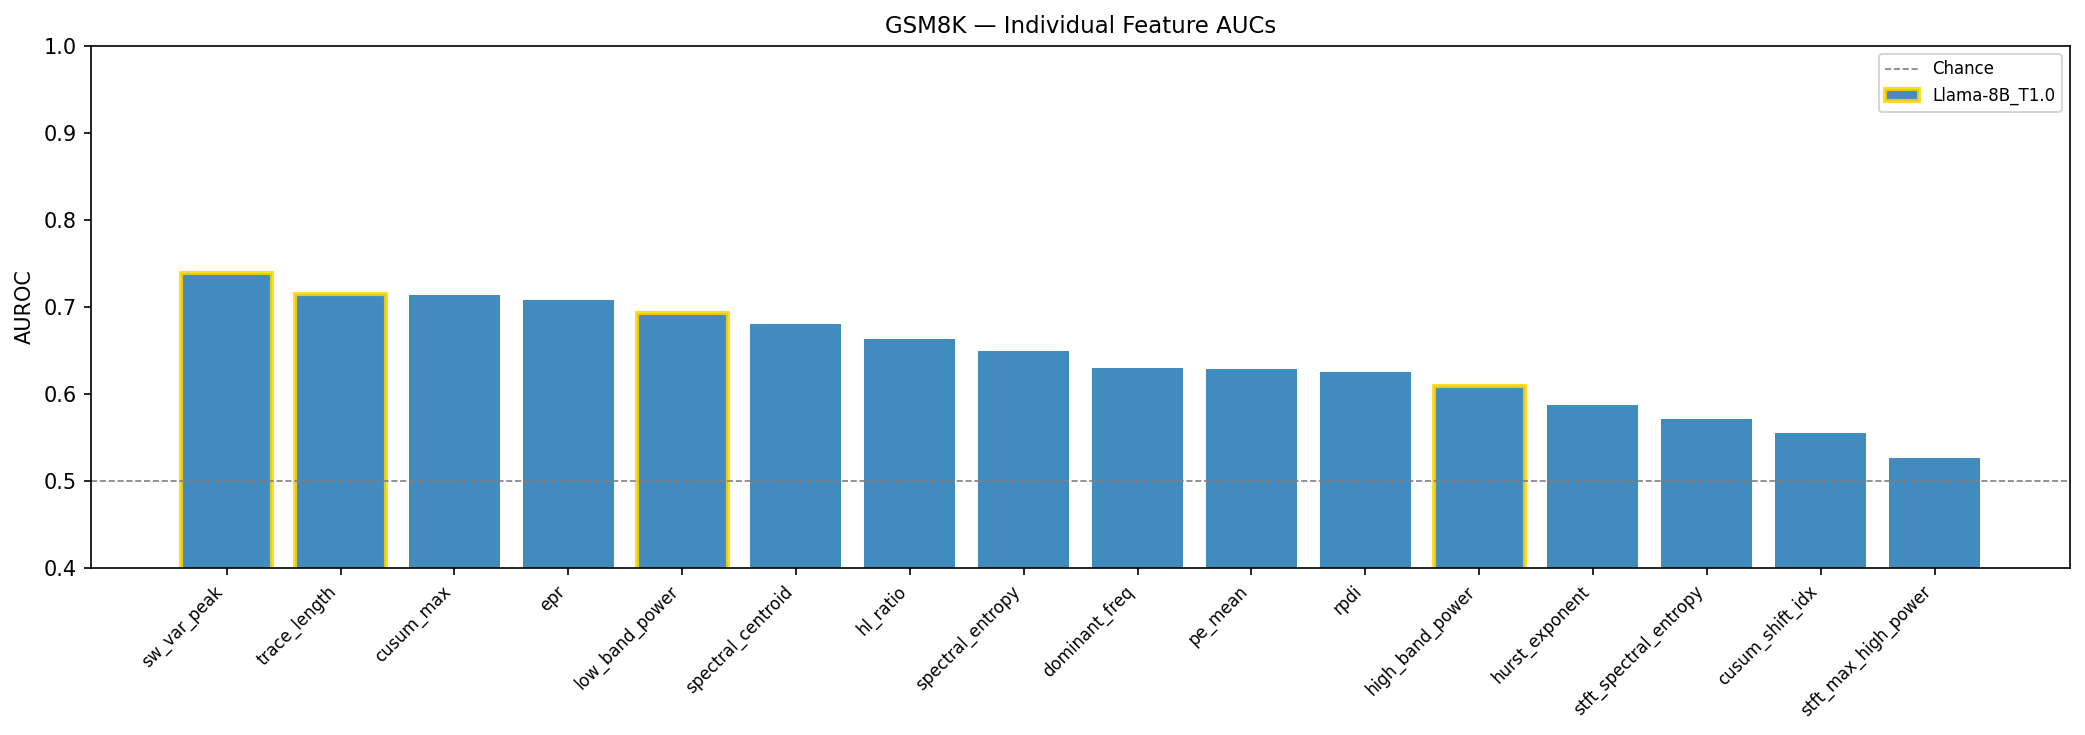

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/gsm8k_nadler_summary.png


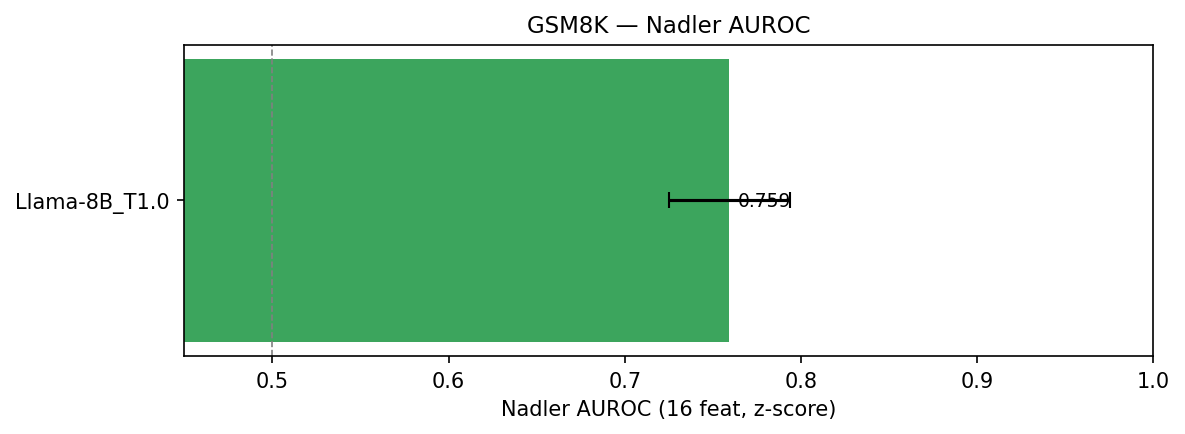

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/gsm8k_llama8b_trajectories.png


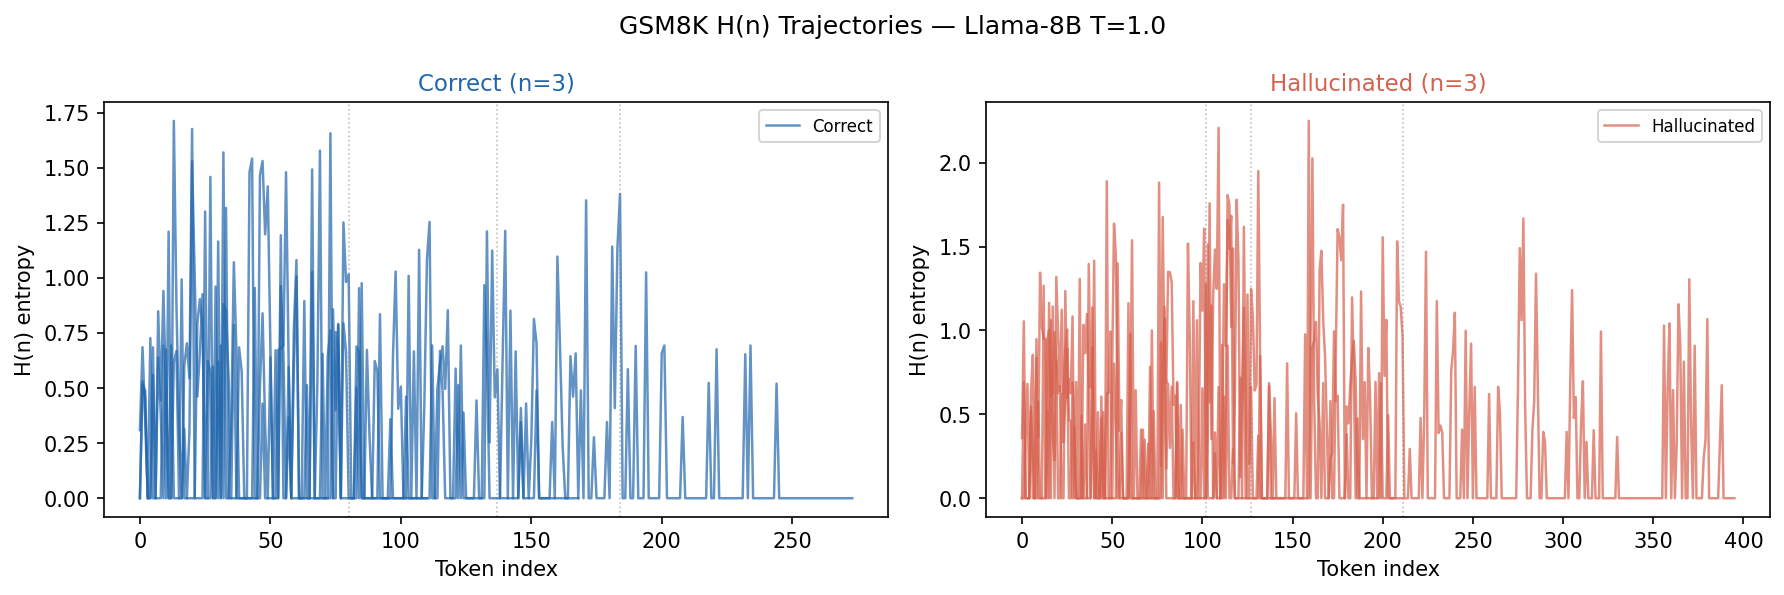

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/gsm8k_avg_psd.png


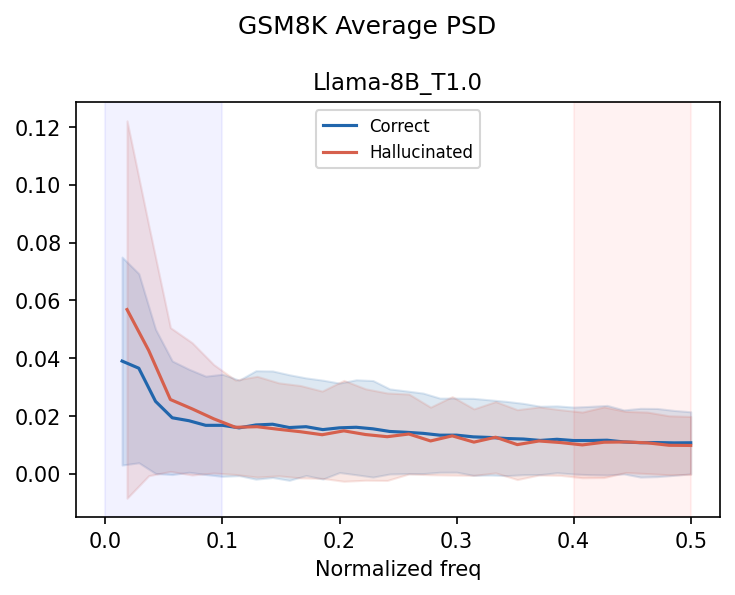

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/gsm8k_feature_distributions.png


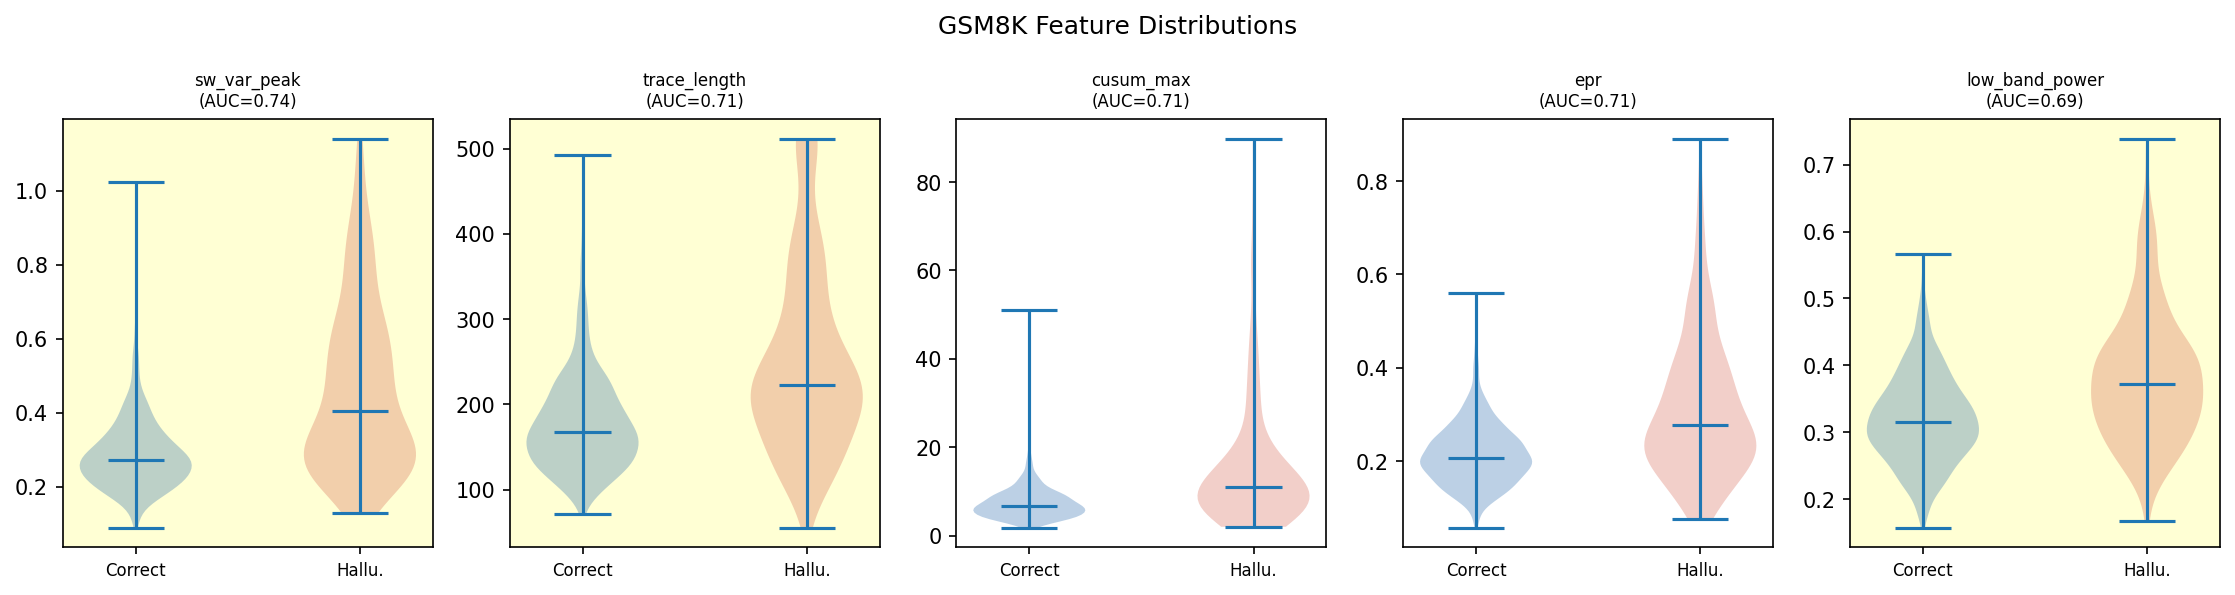

In [11]:
plot_feature_auc_bar(GSM8K_RES, 'GSM8K — Individual Feature AUCs', 'gsm8k_feature_auc_bar.png')
plot_nadler_summary(GSM8K_RES, 'GSM8K — Nadler AUROC', 'gsm8k_nadler_summary.png')
plot_trajectories(GSM8K_DATA['Llama-8B_T1.0'], 'GSM8K H(n) Trajectories — Llama-8B T=1.0',
                  'gsm8k_llama8b_trajectories.png')
plot_avg_psd({'Llama-8B_T1.0': GSM8K_DATA['Llama-8B_T1.0']},
             'GSM8K Average PSD', 'gsm8k_avg_psd.png')
plot_feature_distributions(GSM8K_DATA['Llama-8B_T1.0'], GSM8K_RES.get('Llama-8B_T1.0'),
                           'GSM8K Feature Distributions', 'gsm8k_feature_distributions.png')

## Section 4 — GPQA Diamond (Phases 4/5/8)

In [12]:
# Phase 4/5 GPQA was already loaded above into GPQA_DATA
# Now also load Phase 8 (Qwen-72B-AWQ) if available
print('Loading Phase 8 GPQA (Qwen-72B-AWQ)...')
_gpqa72 = load_domain_data(DATA_ROOTS['gpqa_72b'], ltype='binary')
for (model, dataset, temp), samps in _gpqa72.items():
    key = f'{MODEL_DISPLAY.get(model, model)}_T{temp}'
    GPQA_DATA[key] = samps
    print(f'  Added Phase 8: {key} ({len(samps)} samples)')

print(f'\nAll GPQA groups: {[(k, len(v)) for k, v in GPQA_DATA.items()]}')

Loading Phase 8 GPQA (Qwen-72B-AWQ)...
  Found 2 PKL files in /content/drive/MyDrive/epr_spectral_gpqa_72b


  0%|          | 0/2 [00:00<?, ?it/s]

  Added Phase 8: Qwen2.5-72B-Instruct-AWQ_T1.0 (198 samples)

All GPQA groups: [('Llama-8B_T1.0', 198), ('Qwen-7B_T1.0', 198), ('DeepSeek-R1-Distill-Llama-8B_T1.0', 198), ('Mistral-7B_T1.0', 198), ('Qwen2.5-72B-Instruct-AWQ_T1.0', 198)]


In [13]:
RES_PATH = os.path.join(OUT_DIR, 'gpqa_res.pkl')
FORCE = False

_skip = False
if not FORCE and 'GPQA_RES' in globals() and _valid_res(GPQA_RES):
    print('already in memory'); _skip = True
elif not FORCE and os.path.exists(RES_PATH):
    with open(RES_PATH, 'rb') as _f: saved = pickle.load(_f)
    _r, _ft = saved.get('results', {}), saved.get('feats', {})
    if _valid_res(_r):
        GPQA_RES, GPQA_FEATS = _r, _ft
        print(f'loaded {len(GPQA_RES)} results'); _skip = True
    else:
        print('stale pkl — recomputing')

if not _skip:
    GPQA_FEATS, GPQA_RES = {}, {}
    for key, samps in GPQA_DATA.items():
        print(f'\n[GPQA / {key}]')
        fd, lbl = extract_feats(samps, use_adaptive_window=False)
        GPQA_FEATS[key] = (fd, lbl); GPQA_RES[key] = run_nadler(fd, lbl, key)
    with open(RES_PATH, 'wb') as _f:
        pickle.dump({'results': GPQA_RES, 'feats': GPQA_FEATS}, _f)
    print(f'saved {len(GPQA_RES)} results')

loaded 5 results


saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/gpqa_feature_auc_bar.png


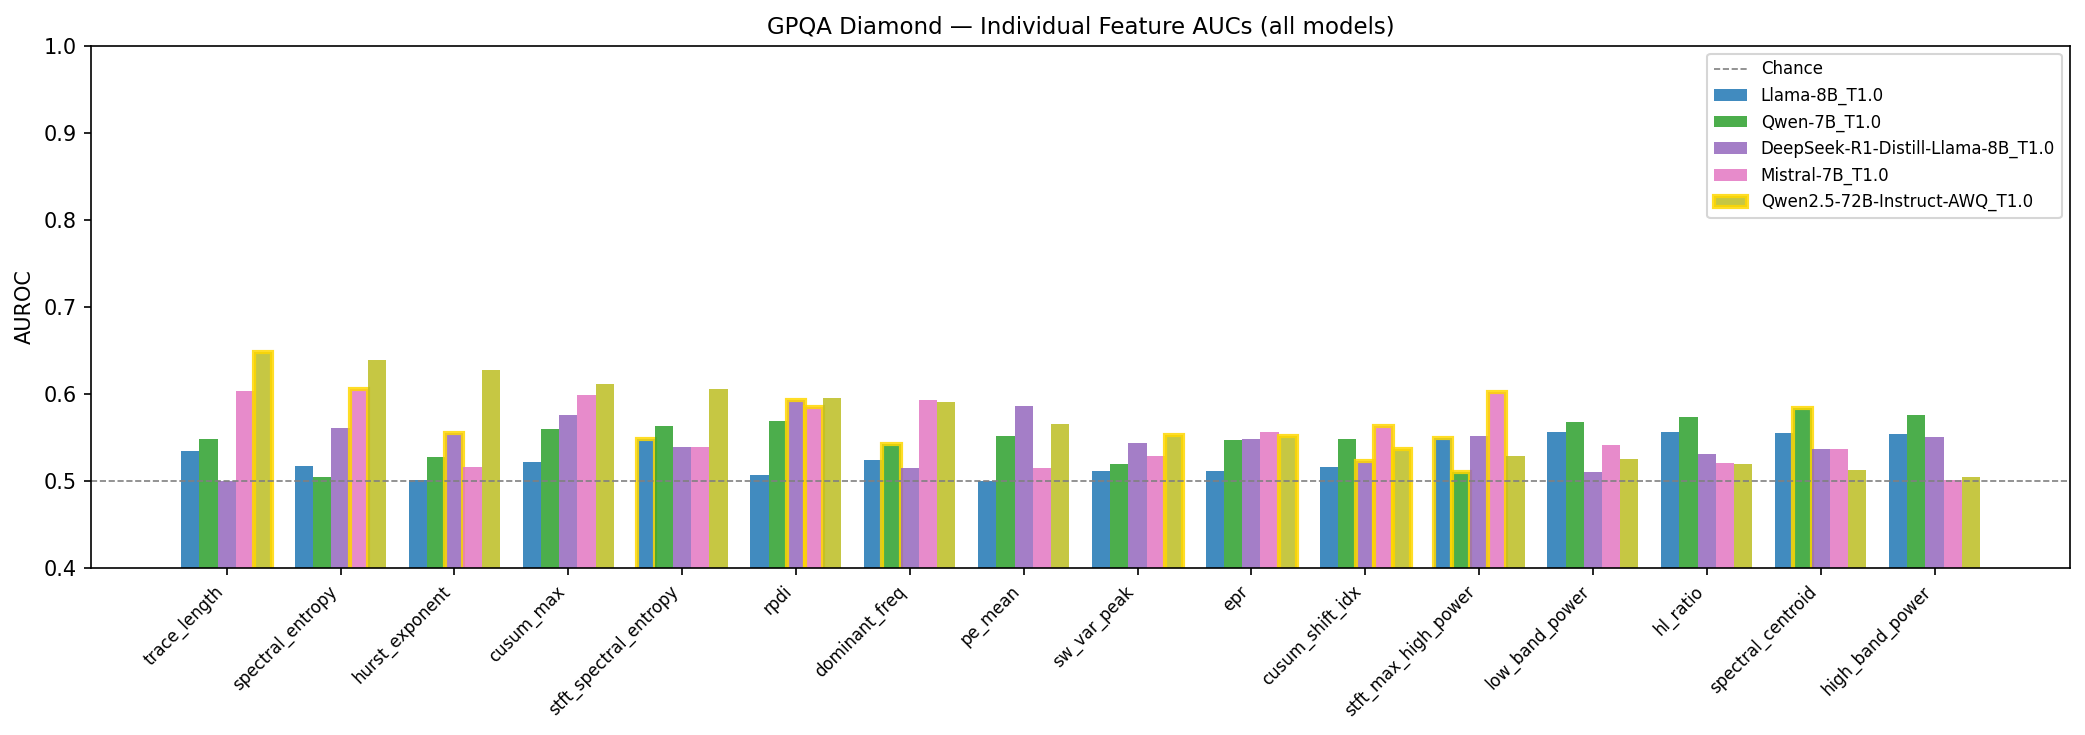

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/gpqa_nadler_summary.png


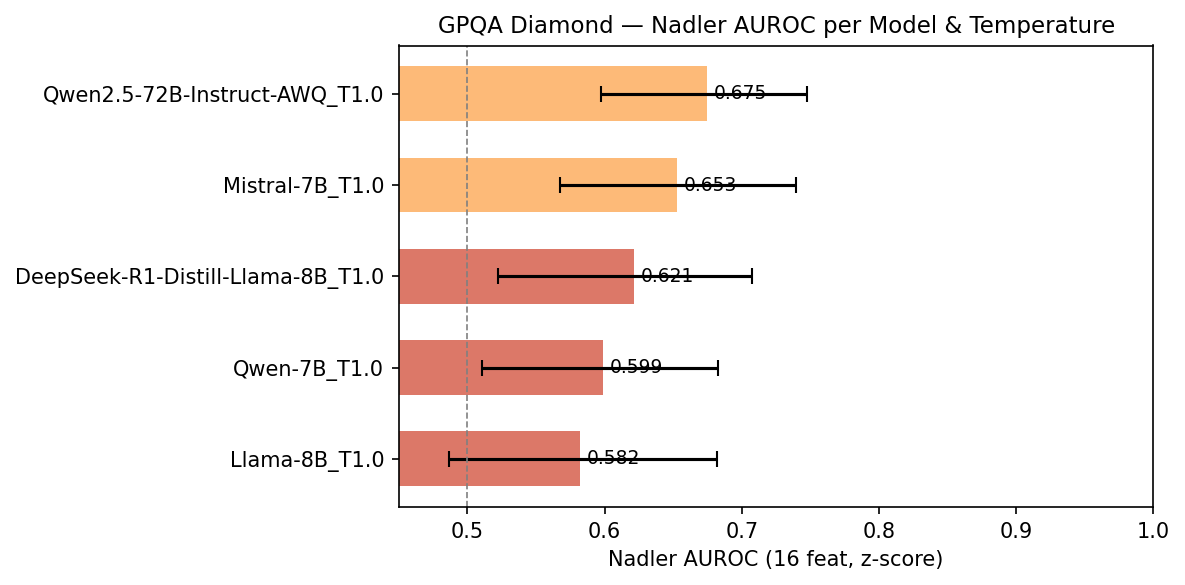

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/gpqa_Qwen2.5-72B-Instruct-AWQ_T1.0_trajectories.png


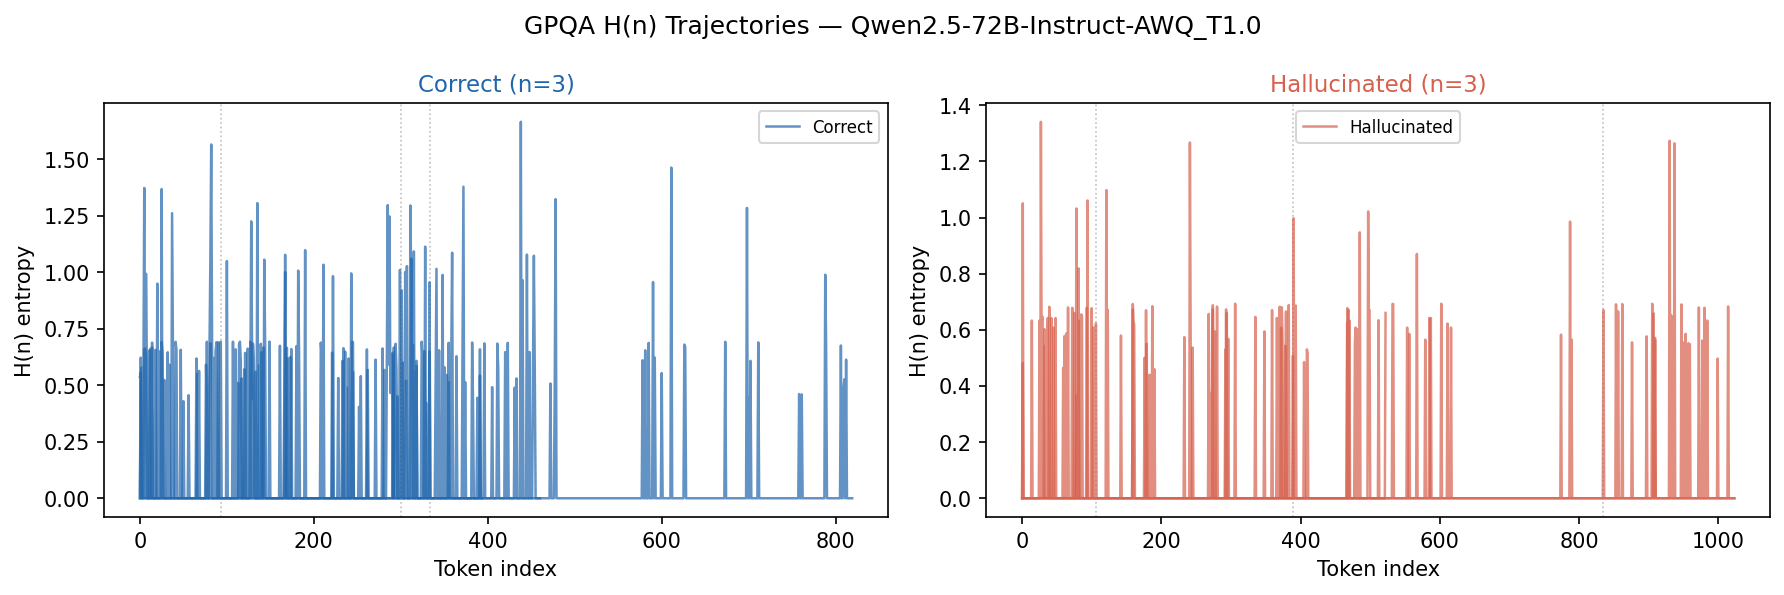

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/gpqa_avg_psd.png


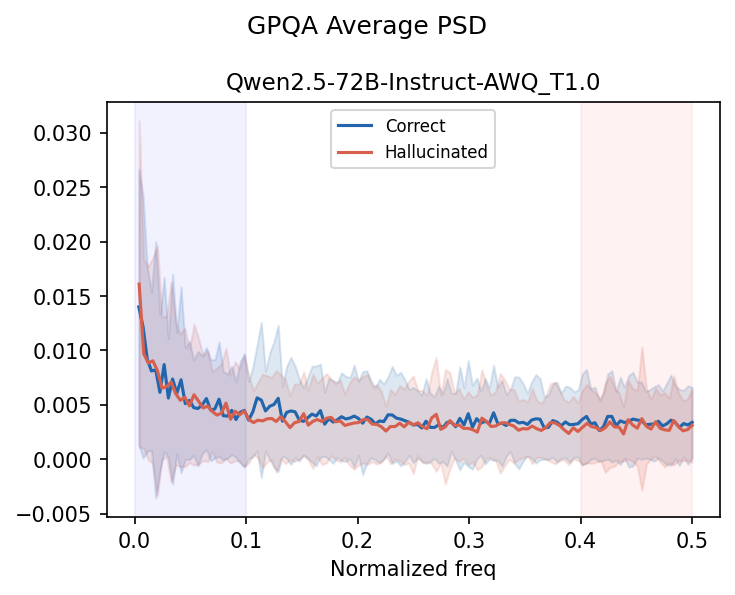

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/gpqa_Qwen2.5-72B-Instruct-AWQ_T1.0_distributions.png


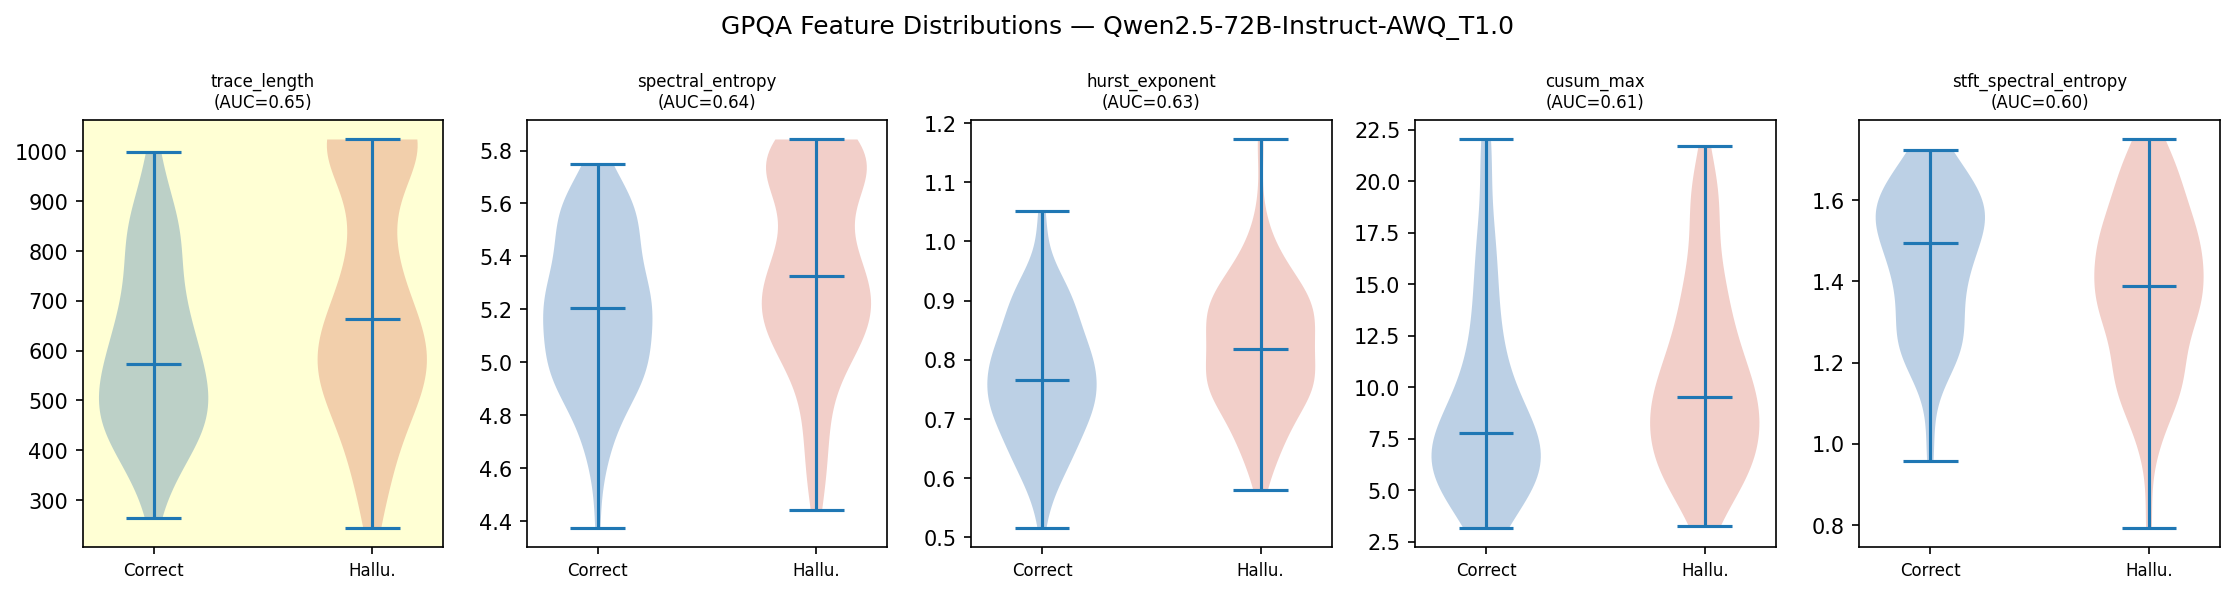

In [14]:
plot_feature_auc_bar(GPQA_RES, 'GPQA Diamond — Individual Feature AUCs (all models)',
                     'gpqa_feature_auc_bar.png')
plot_nadler_summary(GPQA_RES, 'GPQA Diamond — Nadler AUROC per Model & Temperature',
                    'gpqa_nadler_summary.png')
valid_gpqa = {k: v for k, v in GPQA_RES.items() if v}
if valid_gpqa:
    best_gpqa = max(valid_gpqa, key=lambda k: valid_gpqa[k]['nadler_auc'])
    plot_trajectories(GPQA_DATA[best_gpqa], f'GPQA H(n) Trajectories — {best_gpqa}',
                      f'gpqa_{best_gpqa.replace("/","_")}_trajectories.png')
    plot_avg_psd({best_gpqa: GPQA_DATA[best_gpqa]}, 'GPQA Average PSD', 'gpqa_avg_psd.png')
    plot_feature_distributions(GPQA_DATA[best_gpqa], GPQA_RES[best_gpqa],
                               f'GPQA Feature Distributions — {best_gpqa}',
                               f'gpqa_{best_gpqa.replace("/","_")}_distributions.png')

## Section 5 — RAG L-CiteEval (Phase 10)

This section loads raw entropy trajectories from Phase 10 (4 models × 4 datasets), extracts 16
features with adaptive window (short citation-span traces), and runs Nadler per cell.
Feature extraction takes ~10–15 min on CPU — the three-branch reload pattern skips recompute
on subsequent runs.

In [15]:
print('Loading Phase 10 RAG raw trajectories...')
_rag_raw = load_domain_data(DATA_ROOTS['rag_raw'], ltype='statement')

# Map short keys to readable names
RAG_DATA = {}
for (model, dataset, temp), samps in _rag_raw.items():
    m_disp = MODEL_DISPLAY.get(model, model)
    d_disp = dataset.lower().replace('_', '-')
    key = f'{m_disp}/{d_disp}'
    RAG_DATA[key] = samps

print(f'\nRAG cells loaded: {len(RAG_DATA)}')
for k, v in sorted(RAG_DATA.items()): print(f'  {k}: {len(v)} citation-span samples')

Loading Phase 10 RAG raw trajectories...
  Found 16 PKL files in /content/drive/MyDrive/hallucination_detection/cache/phase10_main/raw


  0%|          | 0/16 [00:00<?, ?it/s]


RAG cells loaded: 16
  Llama-8B/2wikimultihopqa: 101 citation-span samples
  Llama-8B/hotpotqa: 96 citation-span samples
  Llama-8B/narrativeqa: 466 citation-span samples
  Llama-8B/natural-questions: 123 citation-span samples
  Mistral-24B/2wikimultihopqa: 47 citation-span samples
  Mistral-24B/hotpotqa: 46 citation-span samples
  Mistral-24B/narrativeqa: 241 citation-span samples
  Mistral-24B/natural-questions: 45 citation-span samples
  Qwen-72B/2wikimultihopqa: 198 citation-span samples
  Qwen-72B/hotpotqa: 169 citation-span samples
  Qwen-72B/narrativeqa: 355 citation-span samples
  Qwen-72B/natural-questions: 197 citation-span samples
  Qwen-7B/2wikimultihopqa: 427 citation-span samples
  Qwen-7B/hotpotqa: 425 citation-span samples
  Qwen-7B/narrativeqa: 328 citation-span samples
  Qwen-7B/natural-questions: 149 citation-span samples


In [16]:
# Feature extraction — SLOW on CPU (~10 min), three-branch reload
FEAT_RES_PATH = os.path.join(OUT_DIR, 'rag_feats_all.pkl')
FORCE_FEATS = False

_skip = False
if not FORCE_FEATS and 'RAG_FEATS' in globals() and len(RAG_FEATS) == len(RAG_DATA) and RAG_FEATS:
    print('RAG_FEATS already in memory'); _skip = True
elif not FORCE_FEATS and os.path.exists(FEAT_RES_PATH):
    with open(FEAT_RES_PATH, 'rb') as _f: _rf = pickle.load(_f)
    if len(_rf) == len(RAG_DATA) and _rf:
        RAG_FEATS = _rf; print(f'Loaded RAG_FEATS ({len(RAG_FEATS)} cells) from disk'); _skip = True
    else:
        print('stale/partial RAG_FEATS pkl — recomputing')

if not _skip:
    RAG_FEATS = {}
    for key, samps in tqdm(RAG_DATA.items(), desc='Extracting RAG features'):
        fd, lbl = extract_feats(samps, use_adaptive_window=True)
        RAG_FEATS[key] = (fd, lbl)
    with open(FEAT_RES_PATH, 'wb') as _f: pickle.dump(RAG_FEATS, _f)
    print(f'Saved RAG_FEATS ({len(RAG_FEATS)} cells) to {FEAT_RES_PATH}')

Loaded RAG_FEATS (16 cells) from disk


In [17]:
RES_PATH = os.path.join(OUT_DIR, 'rag_nadler_res.pkl')
FORCE = False

# Three-branch with partial-resume support:
# 1. All done in memory → skip
# 2. All done on disk → load + skip
# 3. Partial on disk → load + resume (skips already-computed keys)
# 4. Nothing / stale → start fresh
_skip = False
if not FORCE and 'RAG_RES' in globals() and _valid_res(RAG_RES) and len(RAG_RES) == len(RAG_FEATS):
    print(f'in memory — all {len(RAG_RES)} cells done'); _skip = True
elif not FORCE and os.path.exists(RES_PATH):
    with open(RES_PATH, 'rb') as _f: _rr = pickle.load(_f)
    if _valid_res(_rr):
        RAG_RES = _rr
        if len(RAG_RES) == len(RAG_FEATS):
            print(f'loaded all {len(RAG_RES)} results from disk'); _skip = True
        else:
            print(f'partial results on disk ({len(RAG_RES)}/{len(RAG_FEATS)}) — resuming')
    else:
        print('stale pkl — recomputing'); RAG_RES = {}
else:
    RAG_RES = {}

if not _skip:
    if 'RAG_RES' not in globals(): RAG_RES = {}
    remaining = [k for k in RAG_FEATS if k not in RAG_RES or RAG_RES[k] is None]
    done      = [k for k in RAG_FEATS if k in RAG_RES and RAG_RES[k] is not None]
    if done: print(f'  Skipping {len(done)} already-computed: {done}')
    print(f'  Computing {len(remaining)} remaining cells...')
    for key, (fd, lbl) in RAG_FEATS.items():
        if key in RAG_RES and RAG_RES[key] is not None:
            continue
        RAG_RES[key] = run_nadler(fd, lbl, key)
        # Save after every cell — survives mid-run disconnects
        with open(RES_PATH, 'wb') as _f: pickle.dump(RAG_RES, _f)
        print(f'  → saved checkpoint ({len(RAG_RES)}/{len(RAG_FEATS)})')
    print(f'All {len(RAG_RES)} cells done — saved to {RES_PATH}')

loaded all 16 results from disk


saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/rag_auc_heatmap.png


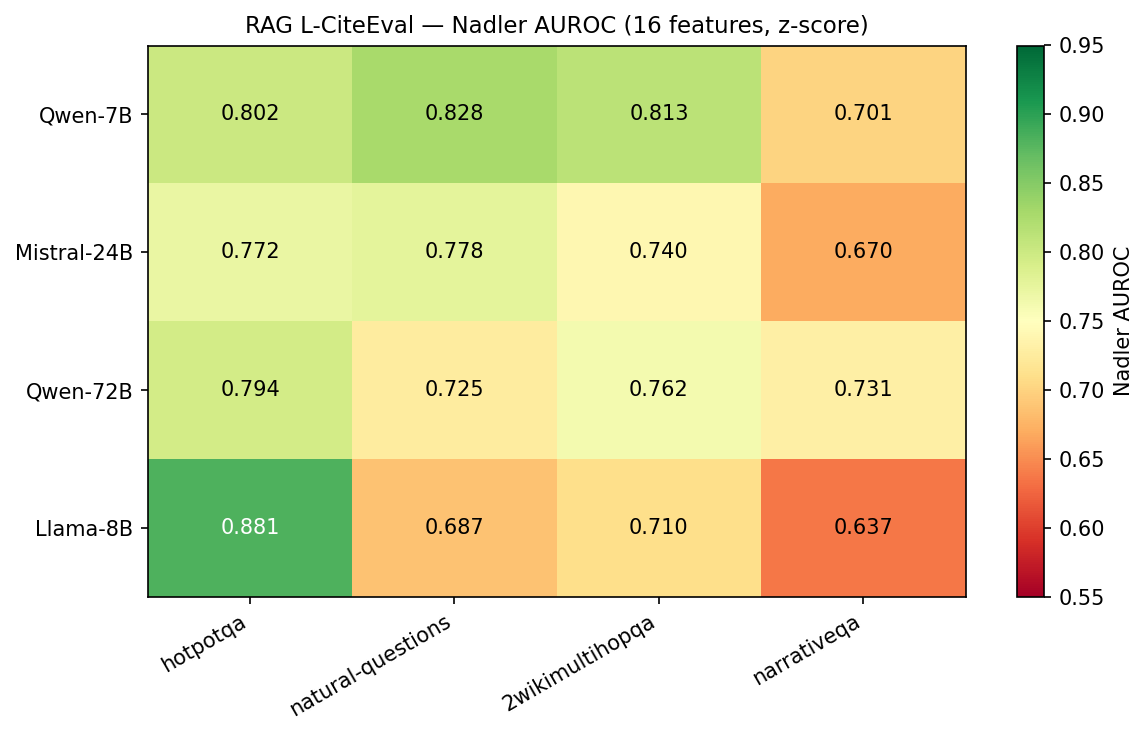


RAG summary: N=16 cells | Median=0.751 | Min=0.637 | Max=0.881 | ≥70%: 13/16


In [18]:
# ── RAG AUC heatmap 4×4 ──────────────────────────────────────────────────────
RAG_MODELS   = ['Qwen-7B', 'Mistral-24B', 'Qwen-72B', 'Llama-8B']
RAG_DATASETS = ['hotpotqa', 'natural-questions', '2wikimultihopqa', 'narrativeqa']

matrix = np.full((len(RAG_MODELS), len(RAG_DATASETS)), np.nan)
for key, res in RAG_RES.items():
    if res is None: continue
    parts = key.split('/')
    if len(parts) < 2: continue
    m, d = parts[0], parts[1]
    if m in RAG_MODELS and d in RAG_DATASETS:
        i, j = RAG_MODELS.index(m), RAG_DATASETS.index(d)
        matrix[i, j] = res['nadler_auc']

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(matrix, vmin=0.55, vmax=0.95, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax, label='Nadler AUROC')
ax.set_xticks(range(len(RAG_DATASETS))); ax.set_xticklabels(RAG_DATASETS, rotation=30, ha='right')
ax.set_yticks(range(len(RAG_MODELS)));   ax.set_yticklabels(RAG_MODELS)
for i in range(len(RAG_MODELS)):
    for j in range(len(RAG_DATASETS)):
        if not np.isnan(matrix[i,j]):
            ax.text(j, i, f'{matrix[i,j]:.3f}', ha='center', va='center',
                    fontsize=10, color='black' if matrix[i,j] < 0.85 else 'white')
ax.set_title('RAG L-CiteEval — Nadler AUROC (16 features, z-score)')
fig.tight_layout()
p = os.path.join(PLOT_DIR, 'rag_auc_heatmap.png')
fig.savefig(p); print(f'saved {p}'); plt.show()

# Print summary
valid_rag = [(k, v['nadler_auc']) for k, v in RAG_RES.items() if v]
if valid_rag:
    vals = [v for _, v in valid_rag]
    print(f'\nRAG summary: N={len(vals)} cells | Median={np.median(vals):.3f} | '
          f'Min={min(vals):.3f} | Max={max(vals):.3f} | ≥70%: {sum(v>=0.70 for v in vals)}/{len(vals)}')

Best RAG cell: Llama-8B/hotpotqa (0.881)
saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/rag_best_cell_feature_auc.png


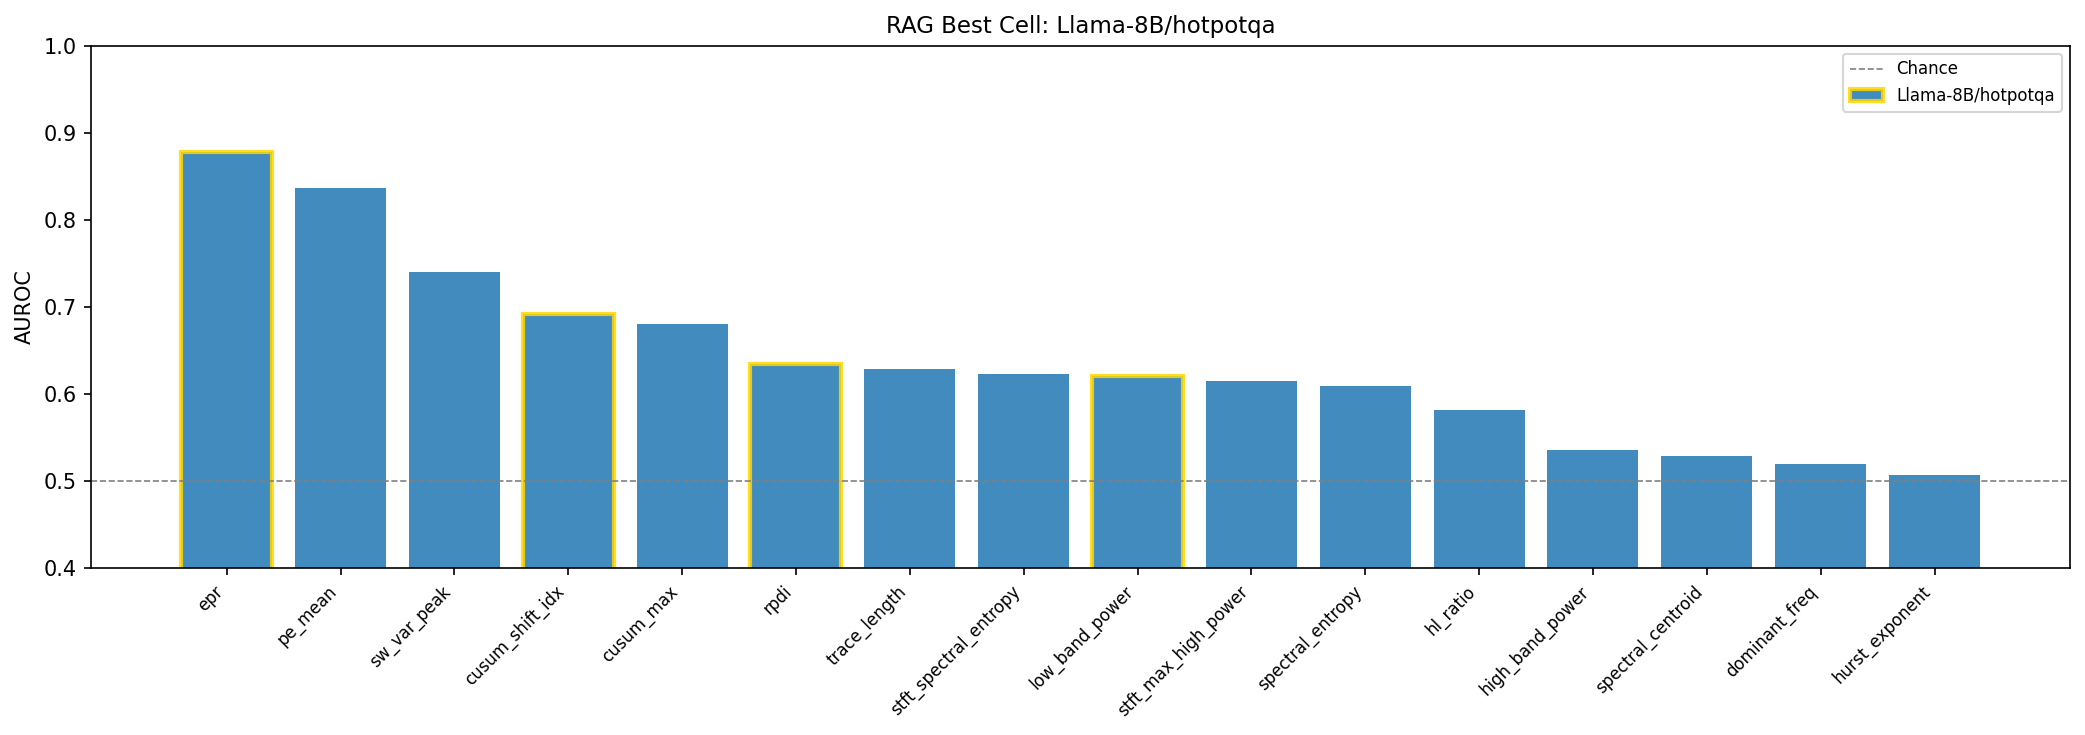

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/rag_best_cell_trajectories.png


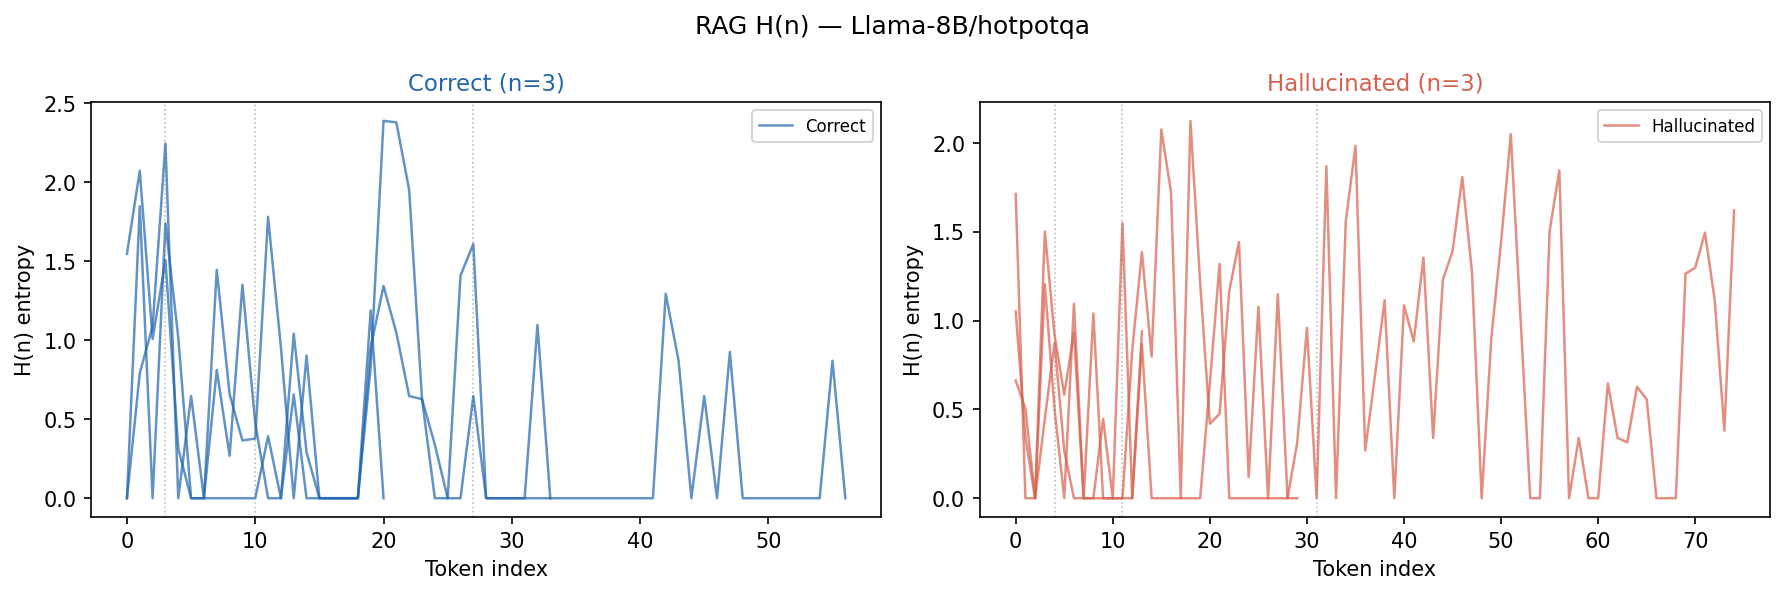

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/rag_qwen7b_avg_psd.png


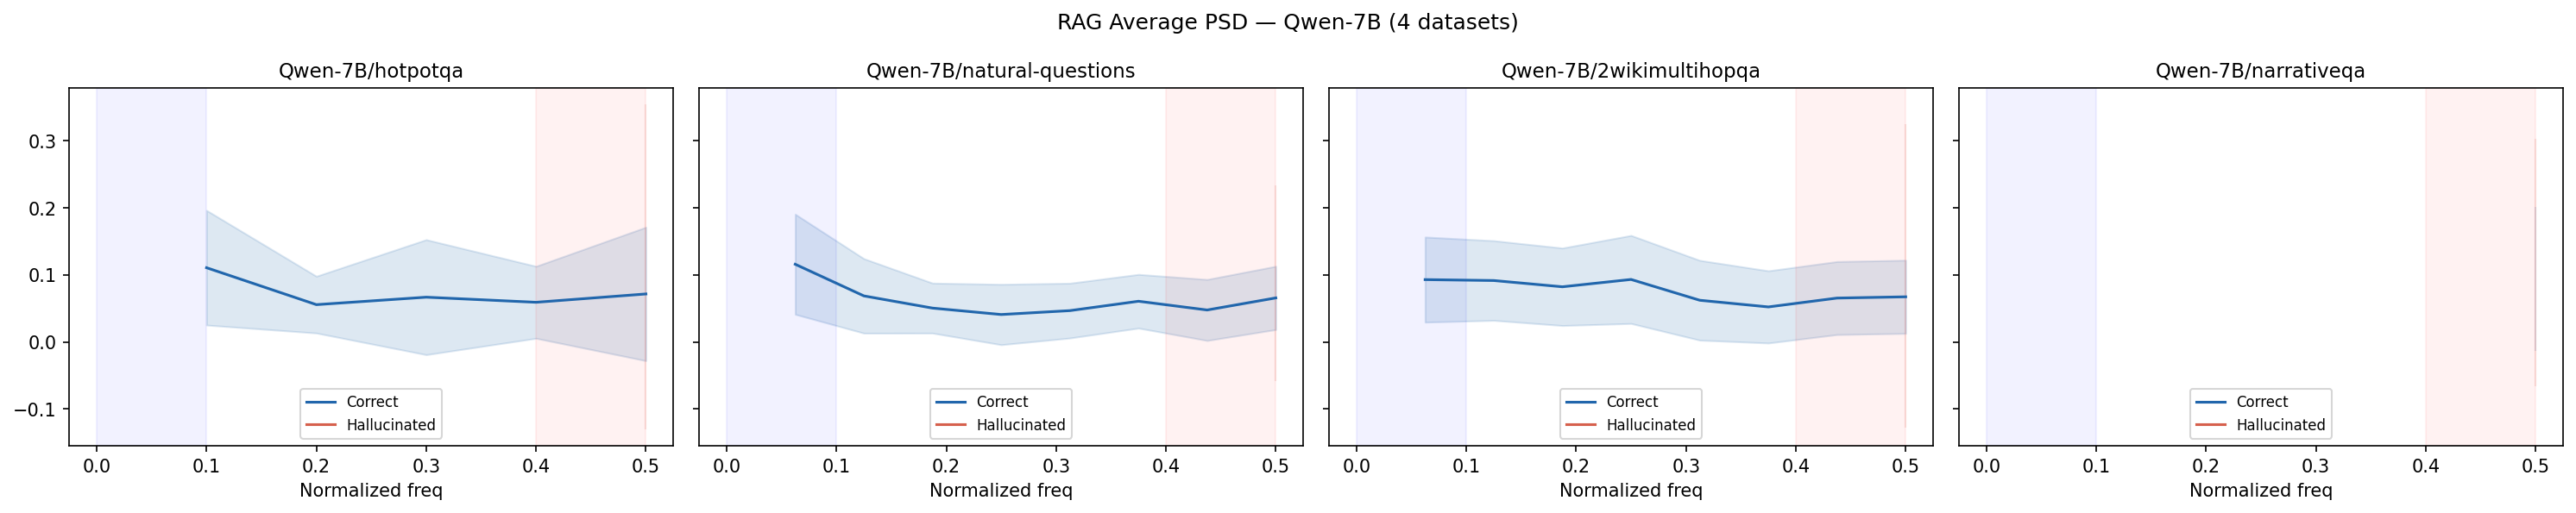

In [19]:
# ── RAG additional plots ──────────────────────────────────────────────────────
valid_rag_res = {k: v for k, v in RAG_RES.items() if v}
if valid_rag_res:
    best_rag_key = max(valid_rag_res, key=lambda k: valid_rag_res[k]['nadler_auc'])
    print(f'Best RAG cell: {best_rag_key} ({valid_rag_res[best_rag_key]["nadler_auc"]:.3f})')
    plot_feature_auc_bar({best_rag_key: valid_rag_res[best_rag_key]},
                         f'RAG Best Cell: {best_rag_key}', 'rag_best_cell_feature_auc.png')
    if best_rag_key in RAG_DATA:
        plot_trajectories(RAG_DATA[best_rag_key], f'RAG H(n) — {best_rag_key}',
                          'rag_best_cell_trajectories.png')

# PSD for qwen7b across 4 datasets
qwen7b_rag = {k: v for k, v in RAG_DATA.items() if k.startswith('Qwen-7B')}
if qwen7b_rag:
    plot_avg_psd(qwen7b_rag, 'RAG Average PSD — Qwen-7B (4 datasets)', 'rag_qwen7b_avg_psd.png')

## Section 6 — Factual QA (Phase 9 — Negative Result)

In [20]:
print('Loading Phase 9 Factual QA caches...')
_qa_raw = load_domain_data(DATA_ROOTS['qa_cot'], ltype='binary')
QA_DATA = {}
for (model, dataset, temp), samps in _qa_raw.items():
    key = f'{MODEL_DISPLAY.get(model, model)}_{dataset}_T{temp}'
    QA_DATA[key] = samps
print(f'QA groups: {[(k, len(v)) for k, v in QA_DATA.items()]}')

QA_RES_PATH = os.path.join(OUT_DIR, 'qa_res.pkl')
FORCE_QA = False
_skip = False
if not FORCE_QA and 'QA_RES' in globals() and _valid_res(QA_RES):
    print('QA results in memory'); _skip = True
elif not FORCE_QA and os.path.exists(QA_RES_PATH):
    with open(QA_RES_PATH, 'rb') as _f: _qr = pickle.load(_f)
    if _valid_res(_qr.get('results', {})):
        QA_FEATS, QA_RES = _qr['feats'], _qr['results']
        print(f'loaded QA results ({len(QA_RES)})'); _skip = True
    else:
        print('stale QA pkl — recomputing')

if not _skip:
    QA_FEATS, QA_RES = {}, {}
    for key, samps in QA_DATA.items():
        print(f'\n[QA / {key}]')
        fd, lbl = extract_feats(samps, use_adaptive_window=True)
        QA_FEATS[key] = (fd, lbl)
        QA_RES[key]   = run_nadler(fd, lbl, key)
    with open(QA_RES_PATH, 'wb') as _f:
        pickle.dump({'results': QA_RES, 'feats': QA_FEATS}, _f)
    print(f'saved QA results ({len(QA_RES)}) to {QA_RES_PATH}')

Loading Phase 9 Factual QA caches...
  Found 4 PKL files in /content/drive/MyDrive/spectral_phase9_cache


  0%|          | 0/4 [00:00<?, ?it/s]

QA groups: [('spectral_phase9_cache_trivia_qa_traces_T1.0', 255), ('spectral_phase9_cache_webq_traces_T1.0', 278), ('spectral_phase9_cache_trivia_qa_cot_traces_T1.0', 300), ('spectral_phase9_cache_webq_cot_traces_T1.0', 300)]
loaded QA results (4)


saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/qa_cot_nadler_bar.png


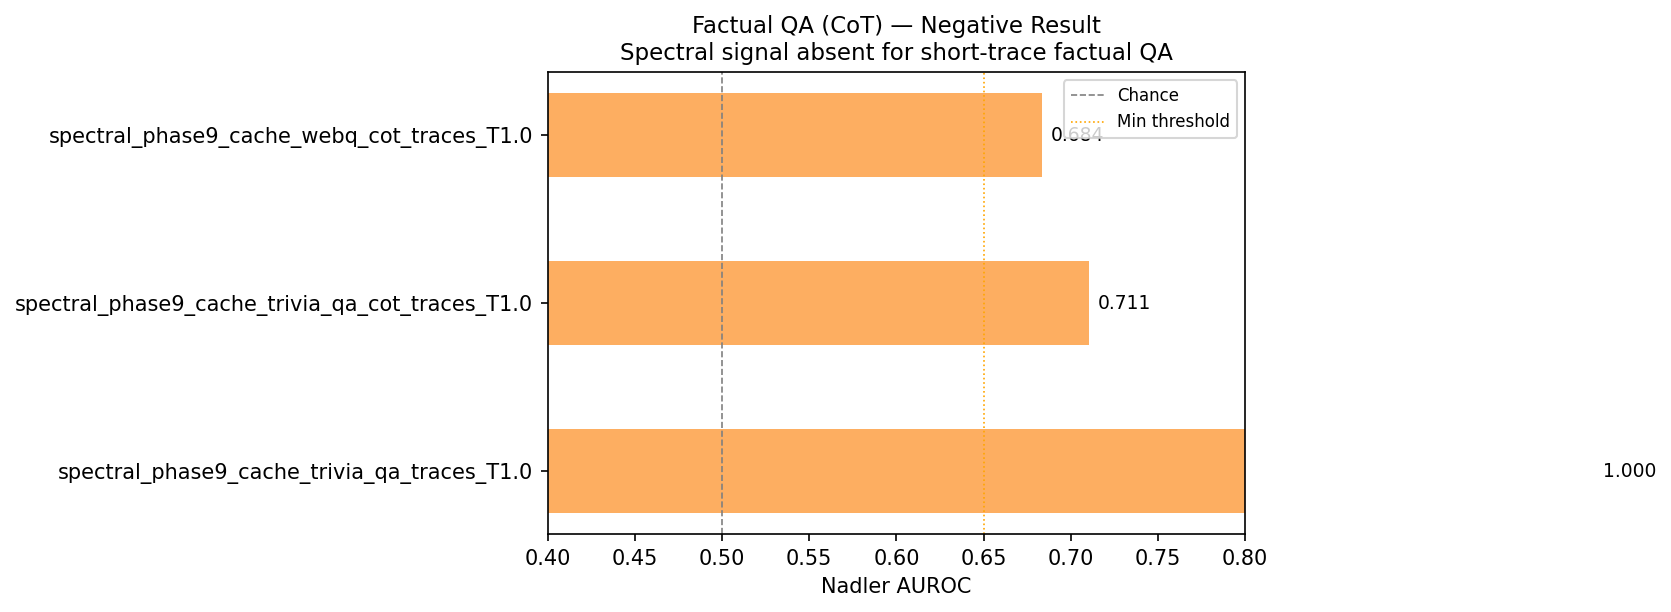

In [21]:
# Single plot showing Factual QA as negative result
valid_qa = {k: v for k, v in QA_RES.items() if v}
if valid_qa:
    fig, ax = plt.subplots(figsize=(6, 4))
    keys  = list(valid_qa.keys())
    vals  = [valid_qa[k]['nadler_auc'] for k in keys]
    colors = ['#d6604d' if v < 0.65 else '#fdae61' for v in vals]
    ax.barh(range(len(keys)), vals, color=colors, height=0.5)
    ax.axvline(0.5, color='gray', linestyle='--', lw=0.8, label='Chance')
    ax.axvline(0.65, color='orange', linestyle=':', lw=0.8, label='Min threshold')
    ax.set_yticks(range(len(keys))); ax.set_yticklabels(keys)
    ax.set_xlabel('Nadler AUROC'); ax.set_xlim(0.4, 0.8)
    ax.set_title('Factual QA (CoT) — Negative Result\n'
                 'Spectral signal absent for short-trace factual QA')
    ax.legend(fontsize=8)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
    fig.tight_layout()
    p = os.path.join(PLOT_DIR, 'qa_cot_nadler_bar.png')
    fig.savefig(p); print(f'saved {p}'); plt.show()

## Section 7 — Global Cross-Domain Analysis

In [22]:
# Pool all samples with domain labels for correlation + RF importance.
# Saved to global_df.pkl — re-running extract_all_features on 7000+ samples takes ~5 min.
GLOBAL_DF_PATH = os.path.join(OUT_DIR, 'global_df.pkl')
FORCE_GLOBAL = False

_skip = False
if not FORCE_GLOBAL and 'GLOBAL_DF' in globals() and len(GLOBAL_DF) > 0:
    print(f'GLOBAL_DF in memory ({len(GLOBAL_DF)} samples)'); _skip = True
elif not FORCE_GLOBAL and os.path.exists(GLOBAL_DF_PATH):
    GLOBAL_DF = pd.read_pickle(GLOBAL_DF_PATH)
    print(f'Loaded GLOBAL_DF from disk ({len(GLOBAL_DF)} samples)'); _skip = True

if not _skip:
    domain_map = [
        ('MATH-500', MATH500_DATA, False),
        ('GSM8K',    GSM8K_DATA,   False),
        ('GPQA',     GPQA_DATA,    False),
        ('RAG',      RAG_DATA,     True),
        ('FactualQA',QA_DATA,      True),
    ]
    all_rows = []
    for domain, data_dict, adaptive in domain_map:
        for key, samps in data_dict.items():
            for s in samps:
                f = extract_all_features(s['ents'])
                if f is None: continue
                if adaptive: f['sw_var_peak'] = sw_var_peak_adaptive(s['ents'])
                row = {'domain': domain, 'label': s['label'], **f}
                all_rows.append(row)
    GLOBAL_DF = pd.DataFrame(all_rows)
    GLOBAL_DF.to_pickle(GLOBAL_DF_PATH)
    print(f'Saved GLOBAL_DF to {GLOBAL_DF_PATH}')

# domain_map must exist for the weight-profile cell below
domain_map = [
    ('MATH-500', MATH500_DATA, False),
    ('GSM8K',    GSM8K_DATA,   False),
    ('GPQA',     GPQA_DATA,    False),
    ('RAG',      RAG_DATA,     True),
    ('FactualQA',QA_DATA,      True),
]

print(f'Global DataFrame: {len(GLOBAL_DF)} samples')
print(GLOBAL_DF.groupby('domain')['label'].value_counts().unstack())

Saved GLOBAL_DF to /content/drive/MyDrive/hallucination_detection/consolidated_results/global_df.pkl
Global DataFrame: 7001 samples
label         0     1
domain               
FactualQA   649   114
GPQA        699   291
GSM8K       276  1043
MATH-500    801   399
RAG        2349   380


saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/global_correlation_heatmap.png


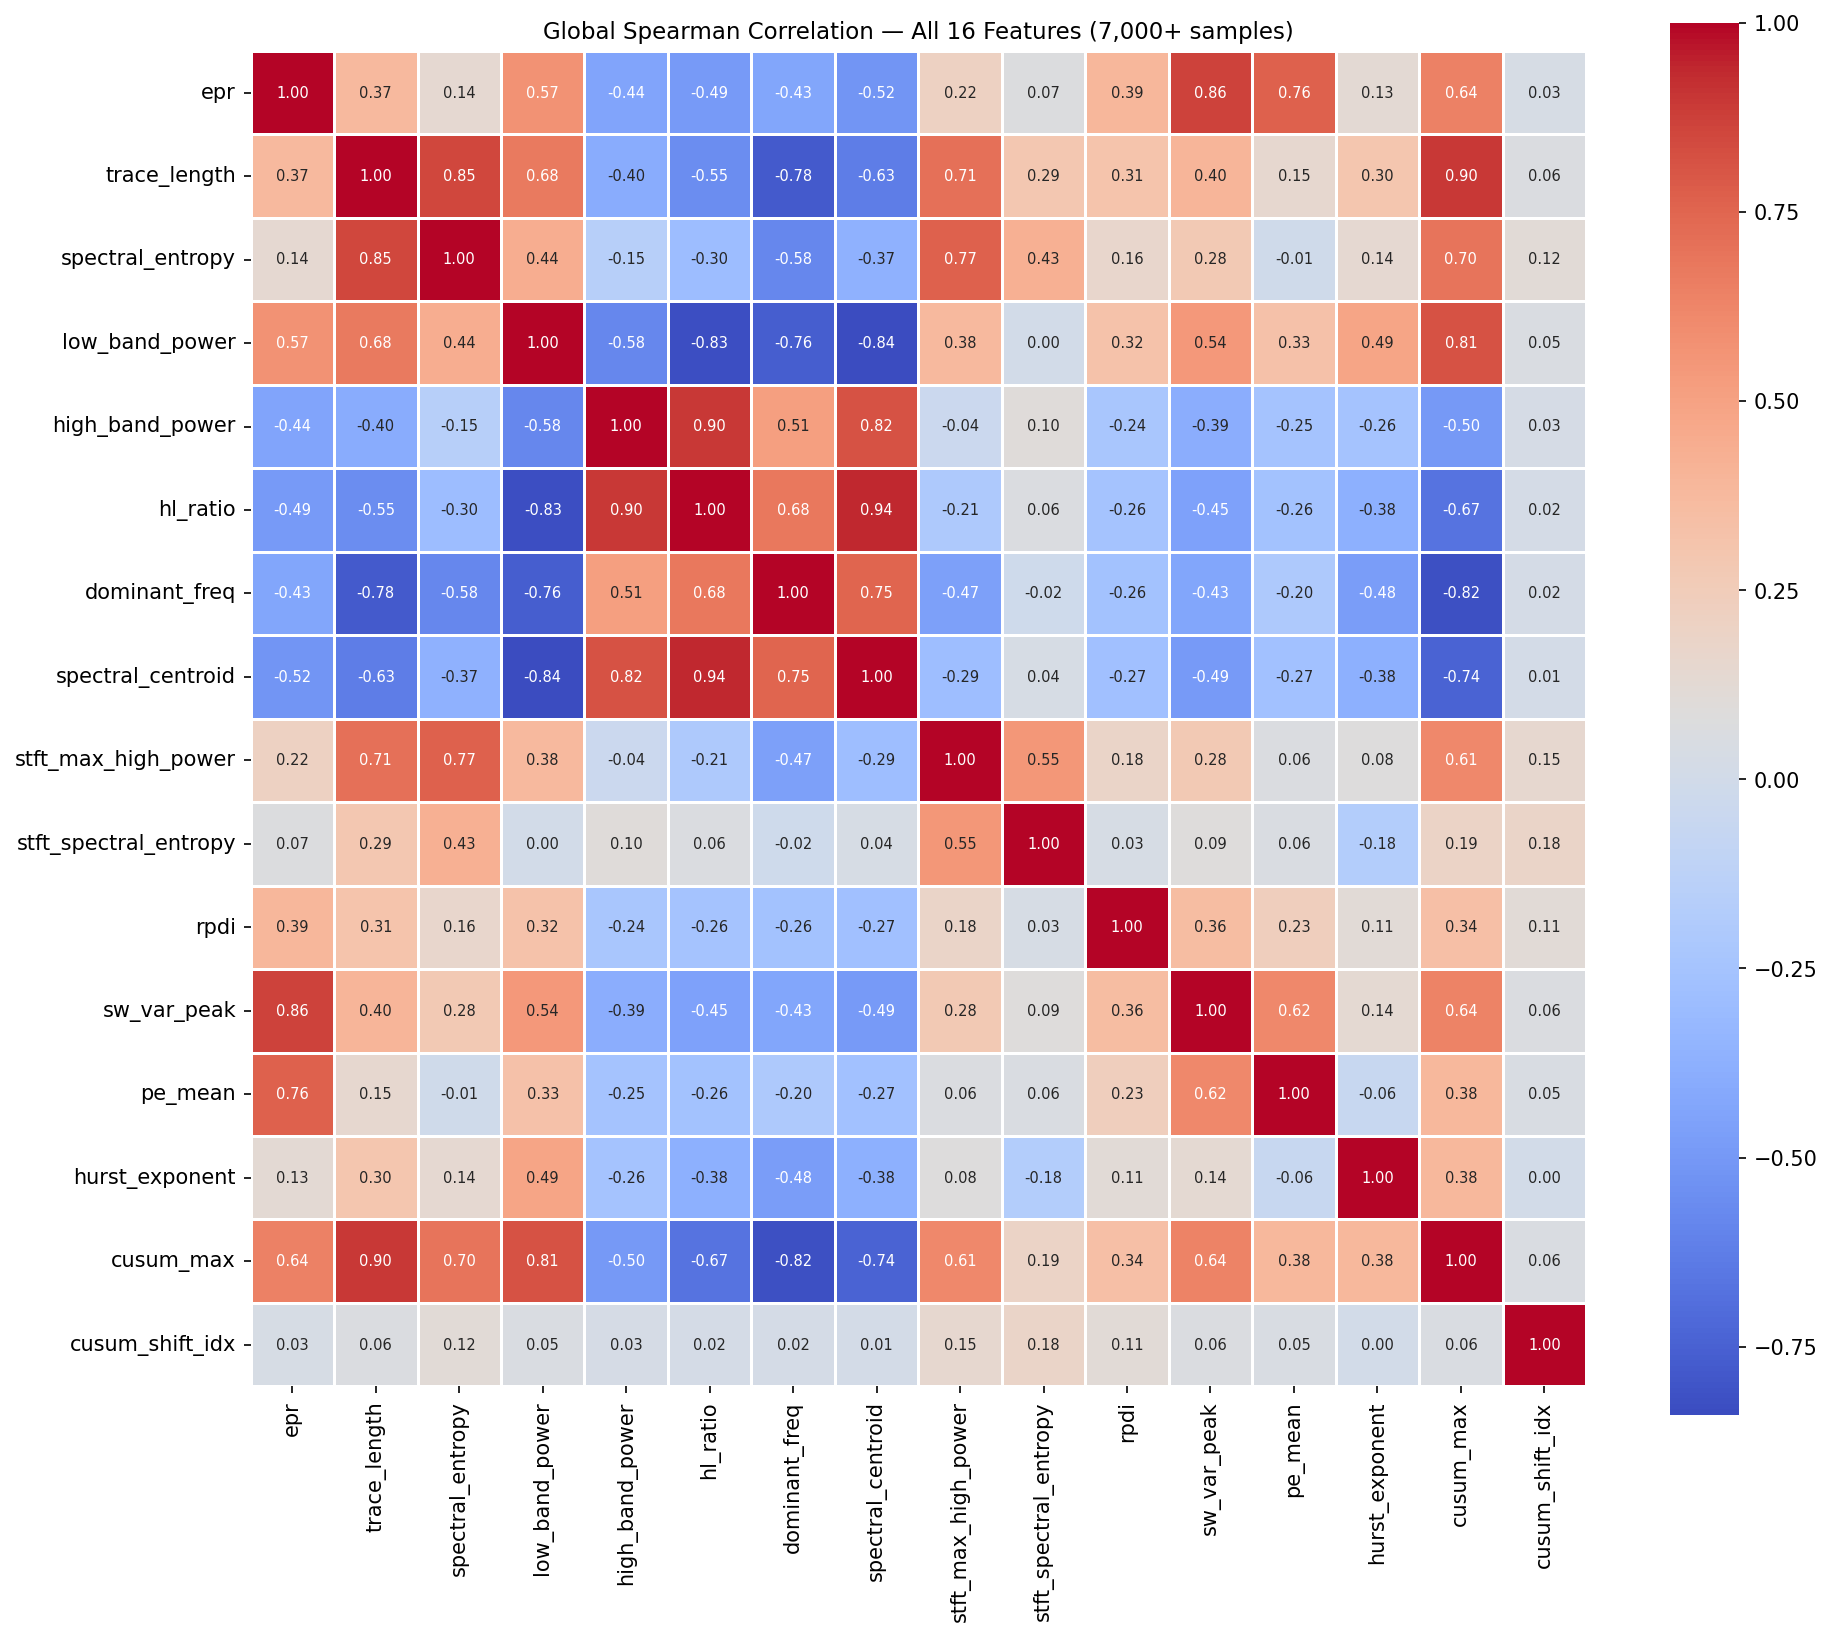

In [23]:
# ── 16×16 Spearman correlation heatmap ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 11))
corr = GLOBAL_DF[FEAT_NAMES].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax,
            square=True, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Global Spearman Correlation — All 16 Features (7,000+ samples)')
fig.tight_layout()
p = os.path.join(PLOT_DIR, 'global_correlation_heatmap.png')
fig.savefig(p); print(f'saved {p}'); plt.show()

  RF done: MATH-500
  RF done: GSM8K
  RF done: GPQA
  RF done: RAG
  RF done: FactualQA
Saved RF importances to /content/drive/MyDrive/hallucination_detection/consolidated_results/global_rf_res.pkl
saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/global_rf_importance_heatmap.png


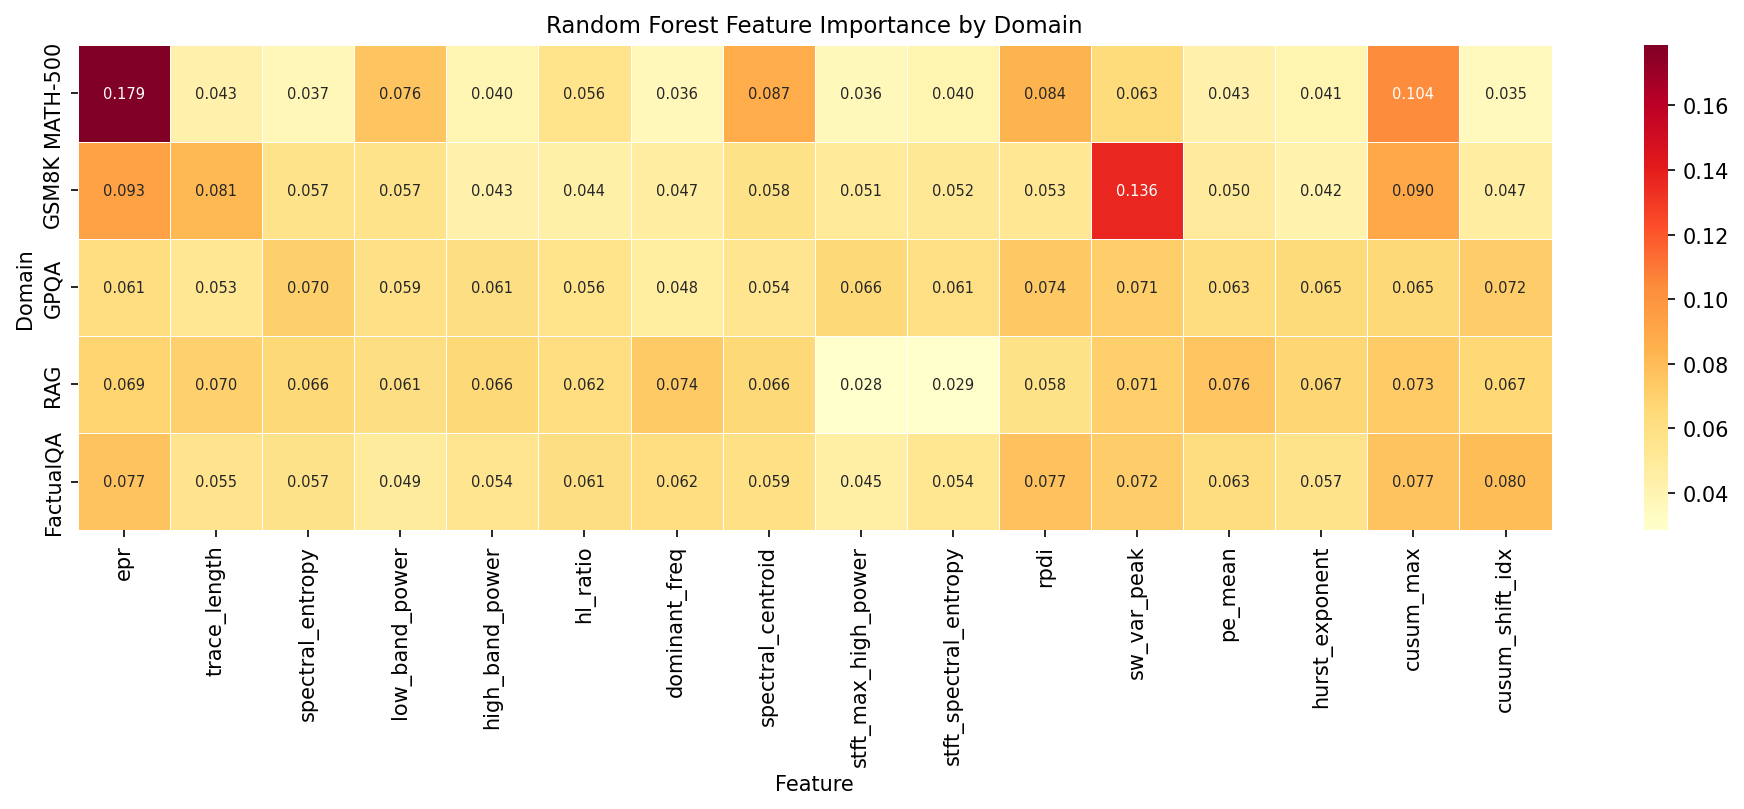


Cross-domain avg rank (1=best):
           avg
MATH-500   8.5
GSM8K      8.5
GPQA       8.5
RAG        8.5
FactualQA  8.5


In [24]:
GLOBAL_RF_PATH = os.path.join(OUT_DIR, 'global_rf_res.pkl')
FORCE_RF = False

_skip = False
if not FORCE_RF and 'domain_importances' in globals() and domain_importances:
    print(f'RF importances in memory ({len(domain_importances)} domains)'); _skip = True
elif not FORCE_RF and os.path.exists(GLOBAL_RF_PATH):
    with open(GLOBAL_RF_PATH, 'rb') as _f: domain_importances = pickle.load(_f)
    print(f'Loaded RF importances from disk ({len(domain_importances)} domains)'); _skip = True

if not _skip:
    domain_importances = {}
    for domain in GLOBAL_DF['domain'].unique():
        sub = GLOBAL_DF[GLOBAL_DF['domain'] == domain]
        if len(sub['label'].unique()) < 2: continue
        X, y = sub[FEAT_NAMES], sub['label']
        rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        rf.fit(X, y)
        domain_importances[domain] = pd.Series(rf.feature_importances_, index=FEAT_NAMES)
        print(f'  RF done: {domain}')
    with open(GLOBAL_RF_PATH, 'wb') as _f: pickle.dump(domain_importances, _f)
    print(f'Saved RF importances to {GLOBAL_RF_PATH}')

if domain_importances:
    imp_df = pd.DataFrame(domain_importances).T  # domains × features
    fig, ax = plt.subplots(figsize=(13, len(imp_df)*0.7 + 2))
    sns.heatmap(imp_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
                linewidths=0.3, annot_kws={'size': 7})
    ax.set_title('Random Forest Feature Importance by Domain')
    ax.set_xlabel('Feature'); ax.set_ylabel('Domain')
    fig.tight_layout()
    p = os.path.join(PLOT_DIR, 'global_rf_importance_heatmap.png')
    fig.savefig(p); print(f'saved {p}'); plt.show()

    # Cross-domain rank
    rank_df = imp_df.rank(axis=1, ascending=False)
    rank_df['avg'] = rank_df.mean(axis=1)
    print('\nCross-domain avg rank (1=best):')
    print(rank_df.sort_values('avg')[['avg']].round(1))

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/global_nadler_weights.png


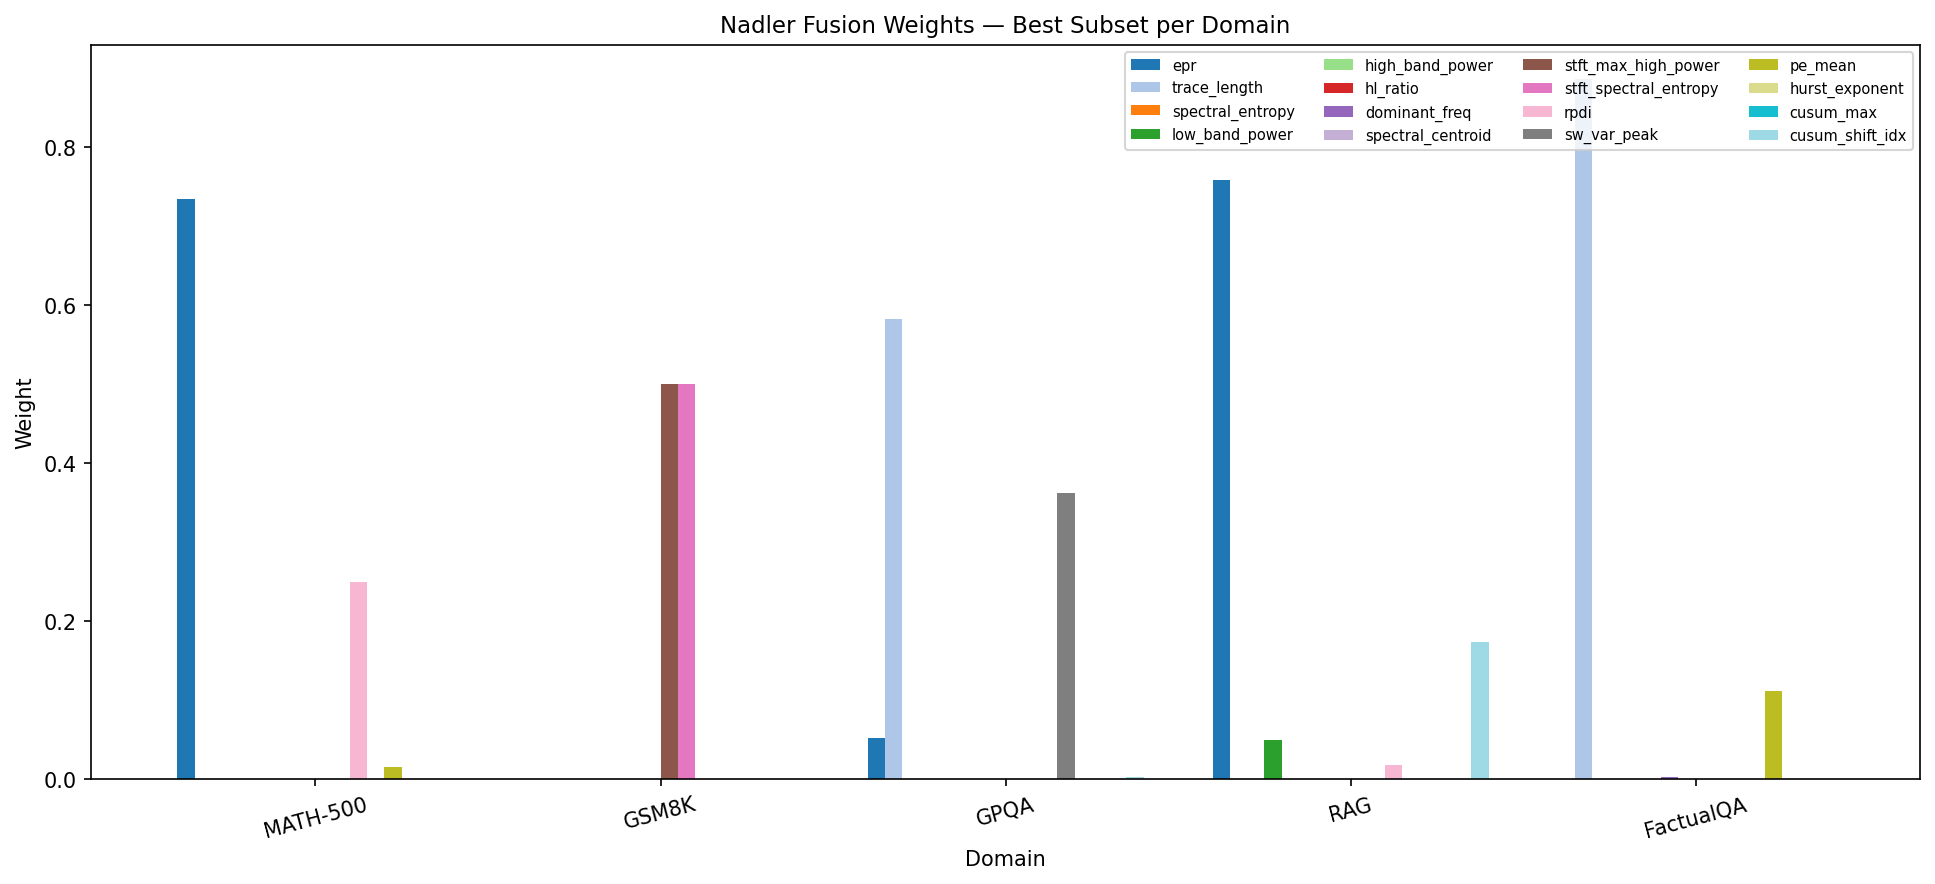

In [25]:
# ── Nadler weight profiles per domain ────────────────────────────────────────
# Aggregate best subset weights per domain (pick highest-AUROC result per domain)
domain_results = {}
for domain, data_dict, _ in domain_map:
    best_key, best_auc = None, 0
    for key in data_dict:
        res_dict = {**MATH500_RES, **GSM8K_RES, **GPQA_RES, **RAG_RES, **QA_RES}
        res = res_dict.get(key)
        if res and res['nadler_auc'] > best_auc:
            best_auc = res['nadler_auc']; best_key = key; best_res = res
    if best_key:
        domain_results[domain] = best_res

if domain_results:
    weight_data = {}
    for domain, res in domain_results.items():
        weights = dict(zip(FEAT_NAMES, [0.0]*len(FEAT_NAMES)))
        for fn, w in zip(res['best_subset'], res['best_weights']):
            weights[fn] = w
        weight_data[domain] = weights

    wdf = pd.DataFrame(weight_data).T[FEAT_NAMES]
    fig, ax = plt.subplots(figsize=(13, len(wdf)*0.8 + 2))
    wdf.plot(kind='bar', ax=ax, stacked=False, width=0.8, colormap='tab20')
    ax.set_title('Nadler Fusion Weights — Best Subset per Domain')
    ax.set_xlabel('Domain'); ax.set_ylabel('Weight')
    ax.legend(fontsize=7, loc='upper right', ncol=4)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
    fig.tight_layout()
    p = os.path.join(PLOT_DIR, 'global_nadler_weights.png')
    fig.savefig(p); print(f'saved {p}'); plt.show()

## Section 8 — Summary Table & Save

In [26]:
# Merge all results into a flat summary
all_res = {
    **{f'MATH500/{k}': v for k, v in MATH500_RES.items() if v},
    **{f'GSM8K/{k}': v   for k, v in GSM8K_RES.items()   if v},
    **{f'GPQA/{k}': v    for k, v in GPQA_RES.items()     if v},
    **{f'RAG/{k}': v     for k, v in RAG_RES.items()       if v},
    **{f'QA/{k}': v      for k, v in QA_RES.items()         if v},
}

rows = []
for full_key, res in sorted(all_res.items(), key=lambda x: -x[1]['nadler_auc']):
    rows.append({
        'domain_model': full_key,
        'nadler_auc':   round(res['nadler_auc'], 4),
        'ci_lo':        round(res['ci_lo'], 4),
        'ci_hi':        round(res['ci_hi'], 4),
        'simple_avg':   round(res['simple_avg_auc'], 4),
        'lift':         round(res['lift'], 4),
        'n_samples':    res['n'],
        'n_pos':        res['n_pos'],
        'best_subset':  '+'.join(res['best_subset']),
    })

summary_df = pd.DataFrame(rows)
print('\n' + '='*80)
print('CONSOLIDATED RESULTS — Updated Official Numbers (16 features, z-score normalization)')
print('='*80)
print(summary_df.to_string(index=False))

csv_path = os.path.join(OUT_DIR, 'results_summary.csv')
summary_df.to_csv(csv_path, index=False)
print(f'\nSaved summary to {csv_path}')

pkl_path = os.path.join(OUT_DIR, 'results_all.pkl')
with open(pkl_path, 'wb') as _f:
    pickle.dump({'math500': MATH500_RES, 'gsm8k': GSM8K_RES,
                 'gpqa': GPQA_RES, 'rag': RAG_RES, 'qa': QA_RES}, _f)
print(f'Saved full results dict to {pkl_path}')


CONSOLIDATED RESULTS — Updated Official Numbers (16 features, z-score normalization)
                                      domain_model  nadler_auc  ci_lo  ci_hi  simple_avg   lift  n_samples  n_pos                                                     best_subset
    QA/spectral_phase9_cache_trivia_qa_traces_T1.0      1.0000 1.0000 1.0000      0.6900 0.3100         52      2                              trace_length+dominant_freq+pe_mean
                         MATH500/Qwen-Math-7B_T1.0      0.9669 0.9390 0.9869      0.9256 0.0413        300     84                                                epr+rpdi+pe_mean
                             RAG/Llama-8B/hotpotqa      0.8815 0.8064 0.9437      0.8454 0.0361         93     29                         epr+low_band_power+rpdi+cusum_shift_idx
           MATH500/Qwen2.5-Math-1.5B-Instruct_T1.0      0.8797 0.8394 0.9149      0.7683 0.1113        300    133                                  epr+dominant_freq+rpdi+pe_mean
         MATH500/DeepSee

saved /content/drive/MyDrive/hallucination_detection/consolidated_results/plots/global_auc_comparison.png


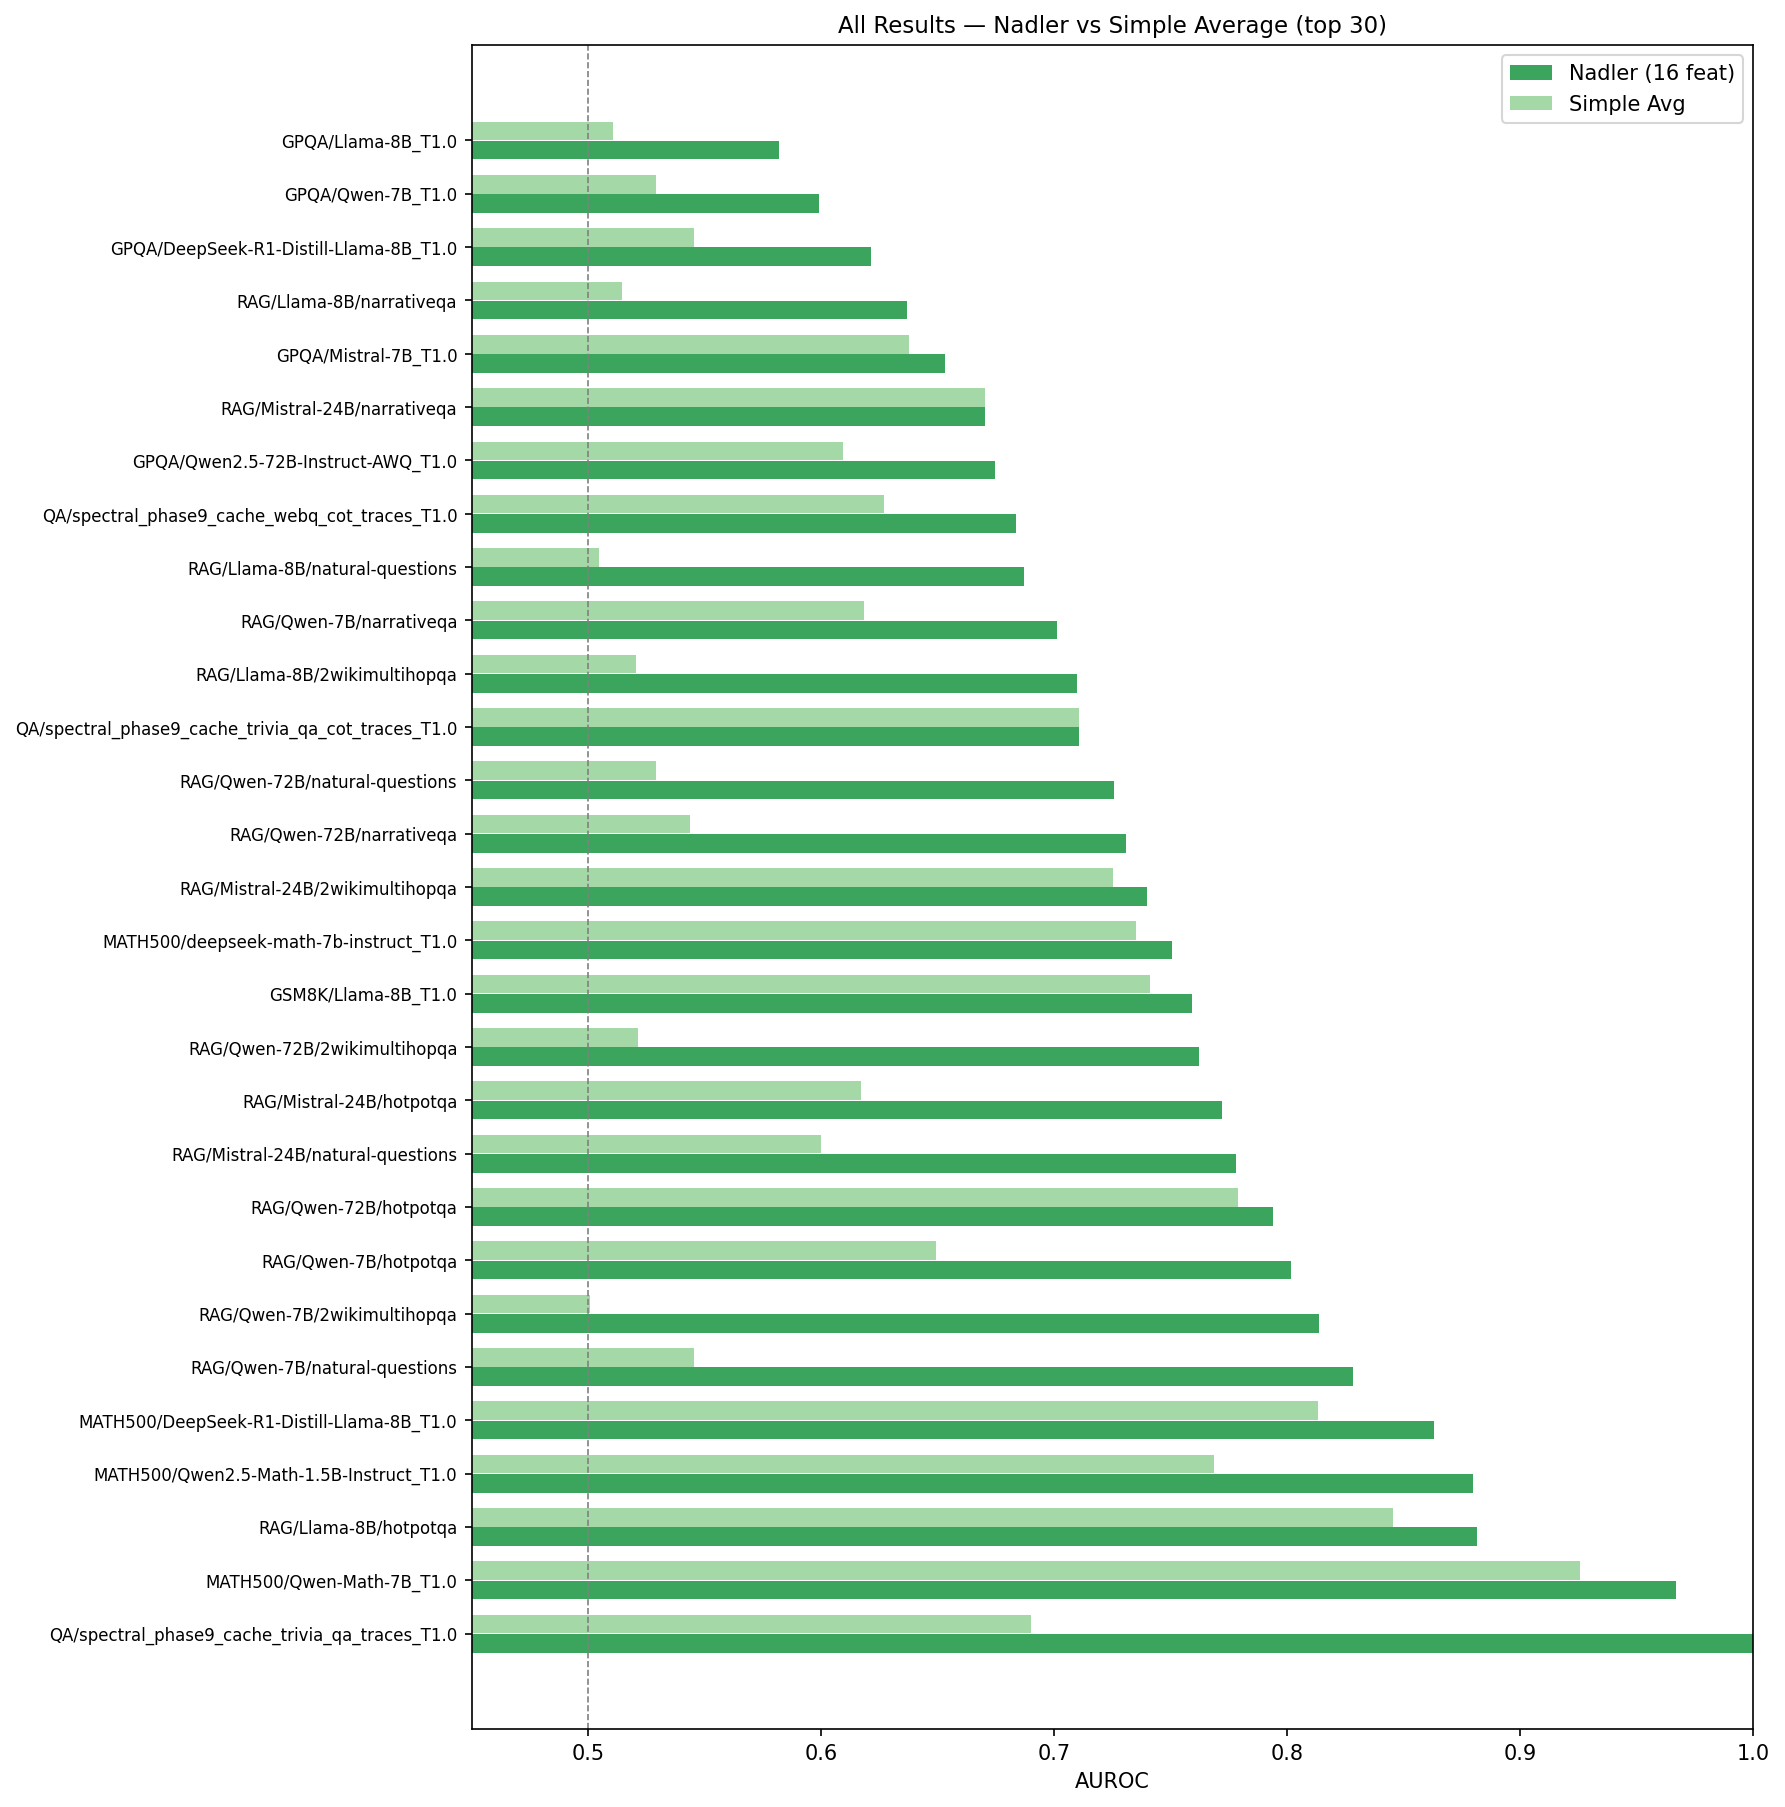


Total plots saved to: /content/drive/MyDrive/hallucination_detection/consolidated_results/plots
Total result cells: 29


In [27]:
# ── Global AUC comparison bar (all domains, all models, sorted) ───────────────
top_n = min(len(all_res), 30)
top_items = sorted(all_res.items(), key=lambda x: -x[1]['nadler_auc'])[:top_n]
keys  = [k for k, _ in top_items]
nadler_vals = [v['nadler_auc'] for _, v in top_items]
simple_vals = [v['simple_avg_auc'] for _, v in top_items]

fig, ax = plt.subplots(figsize=(12, max(5, top_n*0.35 + 2)))
y = np.arange(top_n)
ax.barh(y - 0.18, nadler_vals, 0.35, label='Nadler (16 feat)', color='#1a9641', alpha=0.85)
ax.barh(y + 0.18, simple_vals, 0.35, label='Simple Avg',       color='#74c476', alpha=0.65)
ax.axvline(0.5, color='gray', linestyle='--', lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(keys, fontsize=8)
ax.set_xlabel('AUROC'); ax.set_title('All Results — Nadler vs Simple Average (top 30)')
ax.legend(); ax.set_xlim(0.45, 1.0)
fig.tight_layout()
p = os.path.join(PLOT_DIR, 'global_auc_comparison.png')
fig.savefig(p); print(f'saved {p}'); plt.show()

print(f'\nTotal plots saved to: {PLOT_DIR}')
print(f'Total result cells: {len(all_res)}')

In [28]:
import pickle
import os

# Define the path to save the all_res dictionary in Google Drive
save_path_all_res = os.path.join(OUT_DIR, 'all_results_dict.pkl')

# Save the dictionary
with open(save_path_all_res, 'wb') as f:
    pickle.dump(all_res, f)

print(f'All results dictionary saved to: {save_path_all_res}')

All results dictionary saved to: /content/drive/MyDrive/hallucination_detection/consolidated_results/all_results_dict.pkl
